# 📊 **Pick Your Goal, Build Your Skills**
## The Data Analyst Career Guide for Career Pivoters
---
### *"Which industries and skills give new data analysts the best entry opportunities, highest starting pay, and strongest salary growth potential?"*
---


## **I. Introduction**



Research has shown that data analytics is one of the most financially rewarding and fastest-growing career fields in the United States, with data scientist roles projected to grow 34% by 2034 and senior analysts in Finance and IT earning \$130,000–$133,000 annually (BLS, 2024; Glassdoor, 2026). Notably, official sources confirm that entry into data analytics requires no prior work experience, making it among the most accessible high-paying fields for career pivoters from any background (BLS, 2024). However, little is known about which specific industries offer the most accessible entry points, the highest starting salaries, and the strongest long-term salary growth for those transitioning from unrelated fields. Given the consistent rise in demand for technical skills such as Python, SQL, and Tableau — which are linked to salary premiums of up to 11% above comparable roles (OECD, 2023; IMF, 2026). By analyzing 1,671 U.S. Glassdoor job postings, this study helps career pivoters identify which industries to target and which skills to build — based on what matters most to them.

## **II. Research Objectives**

In particular, this research seeks to answer the following:

#### Industry Demand & Accessibility
- **Which industries have the highest demand for Data Analysts?** — To identify industries with the greatest overall demand.
- **Which industries offer the most accessible entry points for career pivoters?** — To examine which industries provide better entry-level access for applicants with no prior experience.

#### Compensation & Growth
- **Which industries offer the highest average entry-level salary for Data Analysts?** — To determine which industries provide the highest initial compensation.
- **Which industries have the strongest long-term salary growth?** — To evaluate which industries offer the greatest long-term earning potential.


## **III. Data Cleaning**

The dataset was first inspected to understand its structure, data types, and overall quality using exploratory functions such as .info(), .describe(), and .head(). Column names were standardized by converting them to lowercase and formatting them with underscores to maintain consistency.

The dataset was then filtered to focus specifically on Data Analyst roles, ensuring that the analysis remained relevant to the research objective. Placeholder values such as -1 were identified and replaced with "Unknown" to properly represent missing data.

Salary-related fields were cleaned by removing unnecessary text (e.g., "Glassdoor est."), parentheses, and currency symbols. Salary ranges were separated into minimum and maximum salary values, converted from abbreviated formats (e.g., "K") into numeric values, and used to compute an average salary column, allowing for more consistent salary comparisons across roles.

Additional feature engineering was performed by deriving new variables such as Seniority Level (Junior, Mid-Level, Senior) from job titles and Company Size Categories (Small, Medium, Large, Enterprise). Relevant technical skills were extracted from job descriptions using keyword matching to identify commonly required competencies. In addition, years of experience requirements were extracted from job descriptions to estimate the typical experience range associated with different seniority levels and to support analysis of the progression from junior to senior roles.

Finally, a cleaned dataset (df_final) was created containing the relevant variables for analysis, and separate DataFrames were generated for specific segments such as industry groups, seniority levels, and entry-level roles to enable more targeted analysis and visualization.

In [1]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import re

In [2]:
#upload the file
from google.colab import files
uploaded = files.upload()

Saving DataAnalyst.csv to DataAnalyst.csv


In [3]:
#save on a dataframe
df = pd.read_csv('DataAnalyst.csv')
df

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
2250,2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1


In [4]:
#check the first few rows
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE


In [5]:
df.tail()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
2248,2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
2250,2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1
2252,2252,Senior Quality Data Analyst,$78K-$104K (Glassdoor est.),"You.\n\nYou bring your body, mind, heart and s...",3.4,SCL Health\n3.4,"Broomfield, CO","Broomfield, CO",10000+ employees,1864,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),"Centura Health, HealthONE, Denver Health and H...",-1


In [6]:
df.shape

(2253, 16)

In [7]:
#check column and data type
#object = mix of string and integers
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   object 
 2   Salary Estimate    2253 non-null   object 
 3   Job Description    2253 non-null   object 
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   object 
 6   Location           2253 non-null   object 
 7   Headquarters       2253 non-null   object 
 8   Size               2253 non-null   object 
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   object 
 11  Industry           2253 non-null   object 
 12  Sector             2253 non-null   object 
 13  Revenue            2253 non-null   object 
 14  Competitors        2253 non-null   object 
 15  Easy Apply         2253 non-null   object 
dtypes: float64(1), int64(2),

In [8]:
#describe summary values of all columns
df.describe(include='all')

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
count,2253.0000,2253,2253,2253,2253.000000,2252,2253,2253,2253,2253.000000,2253,2253,2253,2253,2253,2253
unique,NaN,1272,90,2253,NaN,1513,253,483,9,NaN,15,89,25,14,291,2
top,NaN,Data Analyst,$41K-$78K (Glassdoor est.),"You.\n\nYou bring your body, mind, heart and s...",NaN,"Staffigo Technical Services, LLC\n5.0","New York, NY","New York, NY",51 to 200 employees,NaN,Company - Private,-1,Information Technology,Unknown / Non-Applicable,-1,-1
freq,NaN,405,57,1,NaN,58,310,206,421,NaN,1273,353,570,615,1732,2173
mean,1126.0000,NaN,NaN,NaN,3.160630,NaN,NaN,NaN,NaN,1398.522858,NaN,NaN,NaN,NaN,NaN,NaN
std,650.5294,NaN,NaN,NaN,1.665228,NaN,NaN,NaN,NaN,901.929251,NaN,NaN,NaN,NaN,NaN,NaN
min,0.0000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,563.0000,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1126.0000,NaN,NaN,NaN,3.600000,NaN,NaN,NaN,NaN,1979.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,1689.0000,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,2002.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#convert columns into lowercase
df.columns = df.columns.str.lower()
df.head()

,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE


In [10]:
#check column content
df['job title']

,job title
0,"Data Analyst, Center on Immigration and Justic..."
1,Quality Data Analyst
2,"Senior Data Analyst, Insights & Analytics Team..."
3,Data Analyst
4,Reporting Data Analyst
...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...
2249,Senior Data Analyst (Corporate Audit)
2250,"Technical Business Analyst (SQL, Data analytic..."
2251,"Data Analyst 3, Customer Experience"


In [11]:
#add new column to categorize data analyst positions

In [12]:
# Check if any cell has the value -1
if (df == -1).any().any():
    print("The value -1 is present in the DataFrame.")
    columns_with_neg_one = df.columns[(df == -1).any()].tolist()
    print(f"Columns containing -1: {columns_with_neg_one}")
else:
    print("The value -1 is not present in the DataFrame.")

The value -1 is present in the DataFrame.
Columns containing -1: ['rating', 'founded']


In [13]:
#check if job title cell has null
df["job title"].isnull().sum()

np.int64(0)

In [14]:
#check for any cell in job title with -1 values
(df["job title"] == -1).sum()

np.int64(0)

In [15]:
#in job title column, include only data analyst positions
df = df[df['job title'].str.contains('data analyst', case=False)]
df

,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,2245,Data Analyst Supporting the DEA #20-242,$78K-$104K (Glassdoor est.),Salary:\nPublished Job Title:\nData Analyst Su...,2.8,Forfeiture Support Associates\n2.8,"Centennial, CO","Ashburn, VA",1001 to 5000 employees,2004,Company - Private,Staffing & Outsourcing,Business Services,$50 to $100 million (USD),-1,-1
2247,2247,Marketing/Communications - Data Analyst-Marketing,$78K-$104K (Glassdoor est.),Job Description\nJob Title: Marketing/Communic...,4.1,APN Software Services Inc.\n4.1,"Broomfield, CO","Newark, CA",51 to 200 employees,-1,Company - Private,Computer Hardware & Software,Information Technology,$25 to $50 million (USD),-1,-1
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1


In [16]:
#convert job title from object to string
df.loc[:, 'job title'] = df['job title'].astype(str)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1670 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   unnamed: 0         1670 non-null   int64  
 1   job title          1670 non-null   object 
 2   salary estimate    1670 non-null   object 
 3   job description    1670 non-null   object 
 4   rating             1670 non-null   float64
 5   company name       1669 non-null   object 
 6   location           1670 non-null   object 
 7   headquarters       1670 non-null   object 
 8   size               1670 non-null   object 
 9   founded            1670 non-null   int64  
 10  type of ownership  1670 non-null   object 
 11  industry           1670 non-null   object 
 12  sector             1670 non-null   object 
 13  revenue            1670 non-null   object 
 14  competitors        1670 non-null   object 
 15  easy apply         1670 non-null   object 
dtypes: float64(1), int64(2), obje

In [18]:
#remove "glassdoor" from salary estimate column
df['salary estimate'] = df['salary estimate'].str.replace('Glassdoor est.', '')
df.head()

/tmp/ipykernel_2127/387175754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['salary estimate'] = df['salary estimate'].str.replace('Glassdoor est.', '')


,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE
1,1,Quality Data Analyst,$37K-$66K (),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE


In [19]:
#remove () from salary estimate column
df['salary estimate'] = df['salary estimate'].str.replace('(', '')
df['salary estimate']


/tmp/ipykernel_2127/3418814941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['salary estimate'] = df['salary estimate'].str.replace('(', '')


,salary estimate
0,$37K-$66K )
1,$37K-$66K )
2,$37K-$66K )
3,$37K-$66K )
4,$37K-$66K )
...,...
2245,$78K-$104K )
2247,$78K-$104K )
2249,$78K-$104K )
2251,$78K-$104K )


In [20]:
#remove () from salary estimate column
df['salary estimate'] = df['salary estimate'].str.replace(')', '')
df['salary estimate']


/tmp/ipykernel_2127/4103408433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['salary estimate'] = df['salary estimate'].str.replace(')', '')


,salary estimate
0,$37K-$66K
1,$37K-$66K
2,$37K-$66K
3,$37K-$66K
4,$37K-$66K
...,...
2245,$78K-$104K
2247,$78K-$104K
2249,$78K-$104K
2251,$78K-$104K


In [21]:
#create two new columns containing min and max value of salary estimate column
df[['min salary', 'max salary']] = df['salary estimate'].str.split('-', expand=True)
df.head()

/tmp/ipykernel_2127/3186961969.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['min salary', 'max salary']] = df['salary estimate'].str.split('-', expand=True)
/tmp/ipykernel_2127/3186961969.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['min salary', 'max salary']] = df['salary estimate'].str.split('-', expand=True)


,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply,min salary,max salary
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE,$37K,$66K
1,1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,$37K,$66K
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,$37K,$66K
3,3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,$37K,$66K
4,4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE,$37K,$66K


In [22]:
#remove dollar sign and replace K with 000 in min salary and max salary columns
df['min salary'] = df['min salary'].str.replace('$', '').str.replace('K', '000')
df['max salary'] = df['max salary'].str.replace('$', '').str.replace('K', '000')
df

/tmp/ipykernel_2127/2578506221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['min salary'] = df['min salary'].str.replace('$', '').str.replace('K', '000')
/tmp/ipykernel_2127/2578506221.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['max salary'] = df['max salary'].str.replace('$', '').str.replace('K', '000')


,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply,min salary,max salary
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE,37000,66000
1,1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,37000,66000
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37000,66000
3,3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,37000,66000
4,4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE,37000,66000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,2245,Data Analyst Supporting the DEA #20-242,$78K-$104K,Salary:\nPublished Job Title:\nData Analyst Su...,2.8,Forfeiture Support Associates\n2.8,"Centennial, CO","Ashburn, VA",1001 to 5000 employees,2004,Company - Private,Staffing & Outsourcing,Business Services,$50 to $100 million (USD),-1,-1,78000,104000
2247,2247,Marketing/Communications - Data Analyst-Marketing,$78K-$104K,Job Description\nJob Title: Marketing/Communic...,4.1,APN Software Services Inc.\n4.1,"Broomfield, CO","Newark, CA",51 to 200 employees,-1,Company - Private,Computer Hardware & Software,Information Technology,$25 to $50 million (USD),-1,-1,78000,104000
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K,Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1,78000,104000
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K,Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1,78000,104000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1670 entries, 0 to 2252
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   unnamed: 0         1670 non-null   int64  
 1   job title          1670 non-null   object 
 2   salary estimate    1670 non-null   object 
 3   job description    1670 non-null   object 
 4   rating             1670 non-null   float64
 5   company name       1669 non-null   object 
 6   location           1670 non-null   object 
 7   headquarters       1670 non-null   object 
 8   size               1670 non-null   object 
 9   founded            1670 non-null   int64  
 10  type of ownership  1670 non-null   object 
 11  industry           1670 non-null   object 
 12  sector             1670 non-null   object 
 13  revenue            1670 non-null   object 
 14  competitors        1670 non-null   object 
 15  easy apply         1670 non-null   object 
 16  min salary         1670 non-n

In [24]:
#categorize size
def categorize_size(size):
    if size in ["1 to 50 employees", "51 to 200 employees"]:
        return "Small"
    elif size in ["201 to 500 employees", "501 to 1000 employees"]:
        return "Medium"
    elif size == "1001 to 5000 employees":
        return "Large"
    elif size in ["5001 to 10000 employees", "10000+ employees"]:
        return "Enterprise"
    else:
        return "Unknown"

df.loc[:, 'Size_Category'] = df['size'].apply(categorize_size)
df

/tmp/ipykernel_2127/1885719287.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Size_Category'] = df['size'].apply(categorize_size)


,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply,min salary,max salary,Size_Category
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,TRUE,37000,66000,Medium
1,1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,37000,66000,Enterprise
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37000,66000,Large
3,3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,37000,66000,Medium
4,4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE,37000,66000,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,2245,Data Analyst Supporting the DEA #20-242,$78K-$104K,Salary:\nPublished Job Title:\nData Analyst Su...,2.8,Forfeiture Support Associates\n2.8,"Centennial, CO","Ashburn, VA",1001 to 5000 employees,2004,Company - Private,Staffing & Outsourcing,Business Services,$50 to $100 million (USD),-1,-1,78000,104000,Large
2247,2247,Marketing/Communications - Data Analyst-Marketing,$78K-$104K,Job Description\nJob Title: Marketing/Communic...,4.1,APN Software Services Inc.\n4.1,"Broomfield, CO","Newark, CA",51 to 200 employees,-1,Company - Private,Computer Hardware & Software,Information Technology,$25 to $50 million (USD),-1,-1,78000,104000,Small
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K,Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1,78000,104000,Enterprise
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K,Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1,78000,104000,Medium


In [25]:
#convert all "-1" in all columns into "unknown"
df = df.replace("-1", "Unknown")
df = df.replace(-1, "Unknown")
df

,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply,min salary,max salary,Size_Category
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),Unknown,TRUE,37000,66000,Medium
1,1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),Unknown,Unknown,37000,66000,Enterprise
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,Unknown,37000,66000,Large
3,3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),Unknown,Unknown,37000,66000,Medium
4,4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE,37000,66000,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,2245,Data Analyst Supporting the DEA #20-242,$78K-$104K,Salary:\nPublished Job Title:\nData Analyst Su...,2.8,Forfeiture Support Associates\n2.8,"Centennial, CO","Ashburn, VA",1001 to 5000 employees,2004,Company - Private,Staffing & Outsourcing,Business Services,$50 to $100 million (USD),Unknown,Unknown,78000,104000,Large
2247,2247,Marketing/Communications - Data Analyst-Marketing,$78K-$104K,Job Description\nJob Title: Marketing/Communic...,4.1,APN Software Services Inc.\n4.1,"Broomfield, CO","Newark, CA",51 to 200 employees,Unknown,Company - Private,Computer Hardware & Software,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Small
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K,Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",Unknown,78000,104000,Enterprise
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K,Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Medium


In [26]:
def categorize_seniority(title):

    title_lower = str(title).lower()
    if any(kw in title_lower for kw in ['senior', 'sr.', 'sr ', 'lead', 'principal', 'staff', 'director', 'head of', 'manager']):
        return 'Senior'
    elif any(kw in title_lower for kw in ['junior', 'jr.', 'jr ', 'entry', 'associate', 'intern', 'trainee', 'i ', 'level i']):
        return 'Junior'
    else:
        return 'Mid-Level'

df.loc[:, 'Seniority'] = df['job title'].apply(categorize_seniority)
df

,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply,min salary,max salary,Size_Category,Seniority
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),Unknown,TRUE,37000,66000,Medium,Mid-Level
1,1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),Unknown,Unknown,37000,66000,Enterprise,Mid-Level
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,Unknown,37000,66000,Large,Senior
3,3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),Unknown,Unknown,37000,66000,Medium,Mid-Level
4,4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE,37000,66000,Medium,Mid-Level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,2245,Data Analyst Supporting the DEA #20-242,$78K-$104K,Salary:\nPublished Job Title:\nData Analyst Su...,2.8,Forfeiture Support Associates\n2.8,"Centennial, CO","Ashburn, VA",1001 to 5000 employees,2004,Company - Private,Staffing & Outsourcing,Business Services,$50 to $100 million (USD),Unknown,Unknown,78000,104000,Large,Mid-Level
2247,2247,Marketing/Communications - Data Analyst-Marketing,$78K-$104K,Job Description\nJob Title: Marketing/Communic...,4.1,APN Software Services Inc.\n4.1,"Broomfield, CO","Newark, CA",51 to 200 employees,Unknown,Company - Private,Computer Hardware & Software,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Small,Mid-Level
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K,Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",Unknown,78000,104000,Enterprise,Senior
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K,Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Medium,Mid-Level


In [27]:
#count many senior, junior other in Seniority column
df['Seniority'].value_counts()

,count
Seniority,
Mid-Level,1174
Senior,372
Junior,124


In [28]:
# Convert 'min salary' and 'max salary' to numeric, handling potential errors
df['min salary'] = pd.to_numeric(df['min salary'], errors='coerce')
df['max salary'] = pd.to_numeric(df['max salary'], errors='coerce')
df

,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,type of ownership,industry,sector,revenue,competitors,easy apply,min salary,max salary,Size_Category,Seniority
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),Unknown,TRUE,37000,66000,Medium,Mid-Level
1,1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),Unknown,Unknown,37000,66000,Enterprise,Mid-Level
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,Unknown,37000,66000,Large,Senior
3,3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),Unknown,Unknown,37000,66000,Medium,Mid-Level
4,4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE,37000,66000,Medium,Mid-Level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,2245,Data Analyst Supporting the DEA #20-242,$78K-$104K,Salary:\nPublished Job Title:\nData Analyst Su...,2.8,Forfeiture Support Associates\n2.8,"Centennial, CO","Ashburn, VA",1001 to 5000 employees,2004,Company - Private,Staffing & Outsourcing,Business Services,$50 to $100 million (USD),Unknown,Unknown,78000,104000,Large,Mid-Level
2247,2247,Marketing/Communications - Data Analyst-Marketing,$78K-$104K,Job Description\nJob Title: Marketing/Communic...,4.1,APN Software Services Inc.\n4.1,"Broomfield, CO","Newark, CA",51 to 200 employees,Unknown,Company - Private,Computer Hardware & Software,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Small,Mid-Level
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K,Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",Unknown,78000,104000,Enterprise,Senior
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K,Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Medium,Mid-Level


In [29]:
# Create 'avg salary' column
df['avg salary'] = (df['min salary'] + df['max salary']) / 2
df


,unnamed: 0,job title,salary estimate,job description,rating,company name,location,headquarters,size,founded,...,industry,sector,revenue,competitors,easy apply,min salary,max salary,Size_Category,Seniority,avg salary
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K,Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,...,Social Assistance,Non-Profit,$100 to $500 million (USD),Unknown,TRUE,37000,66000,Medium,Mid-Level,51500.0
1,1,Quality Data Analyst,$37K-$66K,Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,...,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),Unknown,Unknown,37000,66000,Enterprise,Mid-Level,51500.0
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K,We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,...,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,Unknown,37000,66000,Large,Senior,51500.0
3,3,Data Analyst,$37K-$66K,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,...,IT Services,Information Technology,$50 to $100 million (USD),Unknown,Unknown,37000,66000,Medium,Mid-Level,51500.0
4,4,Reporting Data Analyst,$37K-$66K,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,...,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,TRUE,37000,66000,Medium,Mid-Level,51500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,2245,Data Analyst Supporting the DEA #20-242,$78K-$104K,Salary:\nPublished Job Title:\nData Analyst Su...,2.8,Forfeiture Support Associates\n2.8,"Centennial, CO","Ashburn, VA",1001 to 5000 employees,2004,...,Staffing & Outsourcing,Business Services,$50 to $100 million (USD),Unknown,Unknown,78000,104000,Large,Mid-Level,91000.0
2247,2247,Marketing/Communications - Data Analyst-Marketing,$78K-$104K,Job Description\nJob Title: Marketing/Communic...,4.1,APN Software Services Inc.\n4.1,"Broomfield, CO","Newark, CA",51 to 200 employees,Unknown,...,Computer Hardware & Software,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Small,Mid-Level,91000.0
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K,Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,...,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",Unknown,78000,104000,Enterprise,Senior,91000.0
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K,Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,...,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),Unknown,Unknown,78000,104000,Medium,Mid-Level,91000.0


In [30]:
#list all the unique names in Seniority column
df['Seniority'].unique()

array(['Mid-Level', 'Senior', 'Junior'], dtype=object)

In [31]:
# extract years of experience

def extract_experience(text):
    if pd.isna(text):
        return None

    text = text.lower()

    match = re.search(r'(\d+)\+?\s*years', text)

    if match:
        return int(match.group(1))
    else:
        return None

df['years_experience'] = df['job description'].apply(extract_experience)

df[['job title','Seniority','years_experience']].head()

,job title,Seniority,years_experience
0,"Data Analyst, Center on Immigration and Justic...",Mid-Level,2.0
1,Quality Data Analyst,Mid-Level,NaN
2,"Senior Data Analyst, Insights & Analytics Team...",Senior,NaN
3,Data Analyst,Mid-Level,3.0
4,Reporting Data Analyst,Mid-Level,2.0


In [32]:
# Create new df containing columns that are only needed

df_final = df[['job title','job description','Seniority','years_experience',
               'size','Size_Category','industry','sector',
               'min salary','max salary','avg salary']]
df_final

,job title,job description,Seniority,years_experience,size,Size_Category,industry,sector,min salary,max salary,avg salary
0,"Data Analyst, Center on Immigration and Justic...",Are you eager to roll up your sleeves and harn...,Mid-Level,2.0,201 to 500 employees,Medium,Social Assistance,Non-Profit,37000,66000,51500.0
1,Quality Data Analyst,Overview\n\nProvides analytical and technical ...,Mid-Level,NaN,10000+ employees,Enterprise,Health Care Services & Hospitals,Health Care,37000,66000,51500.0
2,"Senior Data Analyst, Insights & Analytics Team...",We’re looking for a Senior Data Analyst who ha...,Senior,NaN,1001 to 5000 employees,Large,Internet,Information Technology,37000,66000,51500.0
3,Data Analyst,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,Mid-Level,3.0,201 to 500 employees,Medium,IT Services,Information Technology,37000,66000,51500.0
4,Reporting Data Analyst,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,Mid-Level,2.0,501 to 1000 employees,Medium,Sports & Recreation,"Arts, Entertainment & Recreation",37000,66000,51500.0
...,...,...,...,...,...,...,...,...,...,...,...
2245,Data Analyst Supporting the DEA #20-242,Salary:\nPublished Job Title:\nData Analyst Su...,Mid-Level,NaN,1001 to 5000 employees,Large,Staffing & Outsourcing,Business Services,78000,104000,91000.0
2247,Marketing/Communications - Data Analyst-Marketing,Job Description\nJob Title: Marketing/Communic...,Mid-Level,5.0,51 to 200 employees,Small,Computer Hardware & Software,Information Technology,78000,104000,91000.0
2249,Senior Data Analyst (Corporate Audit),Position:\nSenior Data Analyst (Corporate Audi...,Senior,5.0,10000+ employees,Enterprise,Wholesale,Business Services,78000,104000,91000.0
2251,"Data Analyst 3, Customer Experience",Summary\n\nResponsible for working cross-funct...,Mid-Level,8.0,201 to 500 employees,Medium,Enterprise Software & Network Solutions,Information Technology,78000,104000,91000.0


In [33]:
# Fix column names (lowercase and put underscores)
df_final.columns = df_final.columns.str.lower().str.replace(' ', '_')
df_final

,job_title,job_description,seniority,years_experience,size,size_category,industry,sector,min_salary,max_salary,avg_salary
0,"Data Analyst, Center on Immigration and Justic...",Are you eager to roll up your sleeves and harn...,Mid-Level,2.0,201 to 500 employees,Medium,Social Assistance,Non-Profit,37000,66000,51500.0
1,Quality Data Analyst,Overview\n\nProvides analytical and technical ...,Mid-Level,NaN,10000+ employees,Enterprise,Health Care Services & Hospitals,Health Care,37000,66000,51500.0
2,"Senior Data Analyst, Insights & Analytics Team...",We’re looking for a Senior Data Analyst who ha...,Senior,NaN,1001 to 5000 employees,Large,Internet,Information Technology,37000,66000,51500.0
3,Data Analyst,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,Mid-Level,3.0,201 to 500 employees,Medium,IT Services,Information Technology,37000,66000,51500.0
4,Reporting Data Analyst,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,Mid-Level,2.0,501 to 1000 employees,Medium,Sports & Recreation,"Arts, Entertainment & Recreation",37000,66000,51500.0
...,...,...,...,...,...,...,...,...,...,...,...
2245,Data Analyst Supporting the DEA #20-242,Salary:\nPublished Job Title:\nData Analyst Su...,Mid-Level,NaN,1001 to 5000 employees,Large,Staffing & Outsourcing,Business Services,78000,104000,91000.0
2247,Marketing/Communications - Data Analyst-Marketing,Job Description\nJob Title: Marketing/Communic...,Mid-Level,5.0,51 to 200 employees,Small,Computer Hardware & Software,Information Technology,78000,104000,91000.0
2249,Senior Data Analyst (Corporate Audit),Position:\nSenior Data Analyst (Corporate Audi...,Senior,5.0,10000+ employees,Enterprise,Wholesale,Business Services,78000,104000,91000.0
2251,"Data Analyst 3, Customer Experience",Summary\n\nResponsible for working cross-funct...,Mid-Level,8.0,201 to 500 employees,Medium,Enterprise Software & Network Solutions,Information Technology,78000,104000,91000.0


In [34]:

# ── Define skills with ALL their common aliases ───────────────────────────────
SKILL_PATTERNS = {
    'Python':            [r'python'],
    'SQL':               [r'sql', r'mysql', r'postgresql', r'sql server', r't-sql', r'pl/sql'],
    'Tableau':           [r'tableau'],
    'Excel':             [r'excel', r'microsoft excel', r'ms excel'],
    'Power BI':          [r'power\s*bi', r'powerbi'],
    # ── Safest possible R detection ───────────────────────────────────────────────
'R': [
    r'\br\b(?!\s*&)',        # standalone R but not "R & D"
    r'\br\s+programming\b',  # "R programming"
    r'\brstudio\b',          # RStudio
    r'\br-studio\b',         # R-Studio
    r'\btidyverse\b',        # tidyverse = R ecosystem
    r'\bggplot\b',           # ggplot = R library
    r'\bdplyr\b',            # dplyr = R library
    r'\bshiny\b',            # Shiny = R framework
],
    'Machine Learning':  [r'machine\s*learning', r'\bml\b', r'machine-learning'],
   'AI': [
    r'\bai\b',
    r'artificial intelligence',
    r'a\.i\.',
    r'\bdeep learning\b',      # often used instead of "AI" pre-2022
    r'\bneural network',       # common AI proxy term
    r'\bnatural language',     # NLP = AI adjacent
    r'\bnlp\b',                # NLP abbreviation
    r'\bcomputer vision\b',    # another AI proxy
],
    'Spark':             [r'apache spark', r'\bspark\b'],
    'AWS':               [r'\baws\b', r'amazon web services'],
    'Azure':             [r'\bazure\b', r'microsoft azure'],
    'SAS':               [r'\bsas\b'],
    'Statistics':        [r'statistic', r'statistical', r'\bstats\b'],
    'C#':                [r'c#', r'c-sharp'],
    '.NET':              [r'\.net\b', r'dotnet', r'asp\.net', r'wpf', r'webapi'],
    'C++':               [r'c\+\+'],
    'Django':            [r'django'],
    'Flask':             [r'flask'],
    'TensorFlow':        [r'tensorflow', r'tensor\s*flow'],
    'Docker':            [r'docker'],
    'Git':               [r'\bgit\b', r'github', r'gitlab'],
    'Hadoop':            [r'hadoop'],
    'Pandas':            [r'pandas'],
    'NumPy':             [r'numpy'],
    # ── .NET Ecosystem (consolidated) ────────────────────────────────────────
    'WPF':               [r'\bwpf\b',                      # ← ADDED
                          r'windows\s*presentation\s*foundation'],
    'ASP.NET':           [r'asp\.net',                     # ← ADDED
                          r'asp\s*net',
                          r'asp\.net\s*mvc',
                          r'asp\.net\s*core'],
    'Web API':           [r'\bwebapi\b',                   # ← ADDED
                          r'web\s*api',
                          r'restful\s*api',
                          r'\brest\s*api\b'],
    '.NET':              [r'\.net\b', r'\bdotnet\b',
                          r'\.net\s*core', r'\.net\s*framework'],
}

# ── Flag each skill using alias matching ─────────────────────────────────────
def skill_flag(text, patterns):
    if pd.isna(text):
        return 0
    text_lower = text.lower()
    for pat in patterns:
        if re.search(pat, text_lower, re.IGNORECASE):
            return 1
    return 0

for skill, patterns in SKILL_PATTERNS.items():
    df_final[skill] = df_final['job_description'].apply(lambda x: skill_flag(x, patterns))

SKILLS = list(SKILL_PATTERNS.keys())
df_final['Skill_Count'] = df_final[SKILLS].sum(axis=1)

# ── Print results ─────────────────────────────────────────────────────────────
print('✅ Skills parsed with alias matching. Mention rates:')
for s in SKILLS:
    pct = df_final[s].mean() * 100
    print(f'   {s:<20}: {pct:.1f}%')

/tmp/ipykernel_2127/961556770.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[skill] = df_final['job_description'].apply(lambda x: skill_flag(x, patterns))
/tmp/ipykernel_2127/961556770.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[skill] = df_final['job_description'].apply(lambda x: skill_flag(x, patterns))
/tmp/ipykernel_2127/961556770.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

✅ Skills parsed with alias matching. Mention rates:
   Python              : 29.0%
   SQL                 : 65.6%
   Tableau             : 28.8%
   Excel               : 60.6%
   Power BI            : 11.7%
   R                   : 20.8%
   Machine Learning    : 8.6%
   AI                  : 4.7%
   Spark               : 2.9%
   AWS                 : 6.2%
   Azure               : 2.6%
   SAS                 : 15.9%
   Statistics          : 40.7%
   C#                  : 1.1%
   .NET                : 1.6%
   C++                 : 1.0%
   Django              : 0.2%
   Flask               : 0.1%
   TensorFlow          : 0.3%
   Docker              : 0.2%
   Git                 : 2.9%
   Hadoop              : 6.0%
   Pandas              : 2.1%
   NumPy               : 1.1%
   WPF                 : 0.0%
   ASP.NET             : 0.1%
   Web API             : 0.5%


In [35]:
df_final


,job_title,job_description,seniority,years_experience,size,size_category,industry,sector,min_salary,max_salary,...,TensorFlow,Docker,Git,Hadoop,Pandas,NumPy,WPF,ASP.NET,Web API,Skill_Count
0,"Data Analyst, Center on Immigration and Justic...",Are you eager to roll up your sleeves and harn...,Mid-Level,2.0,201 to 500 employees,Medium,Social Assistance,Non-Profit,37000,66000,...,0,0,1,0,0,0,0,0,0,6
1,Quality Data Analyst,Overview\n\nProvides analytical and technical ...,Mid-Level,NaN,10000+ employees,Enterprise,Health Care Services & Hospitals,Health Care,37000,66000,...,0,0,0,0,0,0,0,0,0,5
2,"Senior Data Analyst, Insights & Analytics Team...",We’re looking for a Senior Data Analyst who ha...,Senior,NaN,1001 to 5000 employees,Large,Internet,Information Technology,37000,66000,...,0,0,0,0,0,0,0,0,0,7
3,Data Analyst,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,Mid-Level,3.0,201 to 500 employees,Medium,IT Services,Information Technology,37000,66000,...,0,0,0,0,0,0,0,0,0,3
4,Reporting Data Analyst,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,Mid-Level,2.0,501 to 1000 employees,Medium,Sports & Recreation,"Arts, Entertainment & Recreation",37000,66000,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,Data Analyst Supporting the DEA #20-242,Salary:\nPublished Job Title:\nData Analyst Su...,Mid-Level,NaN,1001 to 5000 employees,Large,Staffing & Outsourcing,Business Services,78000,104000,...,0,0,0,0,0,0,0,0,0,1
2247,Marketing/Communications - Data Analyst-Marketing,Job Description\nJob Title: Marketing/Communic...,Mid-Level,5.0,51 to 200 employees,Small,Computer Hardware & Software,Information Technology,78000,104000,...,0,0,0,0,0,0,0,0,0,2
2249,Senior Data Analyst (Corporate Audit),Position:\nSenior Data Analyst (Corporate Audi...,Senior,5.0,10000+ employees,Enterprise,Wholesale,Business Services,78000,104000,...,0,0,0,0,0,0,0,0,0,4
2251,"Data Analyst 3, Customer Experience",Summary\n\nResponsible for working cross-funct...,Mid-Level,8.0,201 to 500 employees,Medium,Enterprise Software & Network Solutions,Information Technology,78000,104000,...,0,0,0,1,0,0,0,0,0,6


In [36]:
df_final.columns

Index(['job_title', 'job_description', 'seniority', 'years_experience', 'size',
       'size_category', 'industry', 'sector', 'min_salary', 'max_salary',
       'avg_salary', 'Python', 'SQL', 'Tableau', 'Excel', 'Power BI', 'R',
       'Machine Learning', 'AI', 'Spark', 'AWS', 'Azure', 'SAS', 'Statistics',
       'C#', '.NET', 'C++', 'Django', 'Flask', 'TensorFlow', 'Docker', 'Git',
       'Hadoop', 'Pandas', 'NumPy', 'WPF', 'ASP.NET', 'Web API',
       'Skill_Count'],
      dtype='object')

## **A. Initial Dataframe**

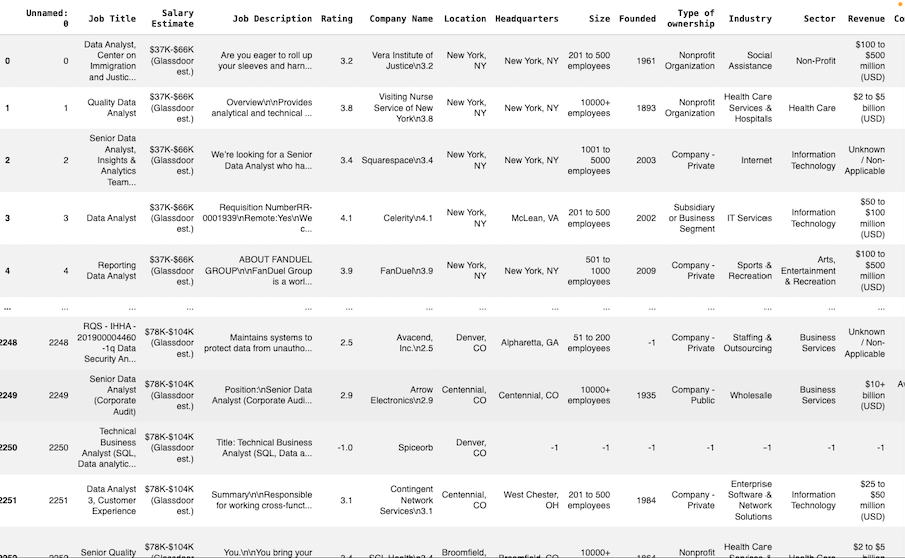

## **B. Final Dataframe**

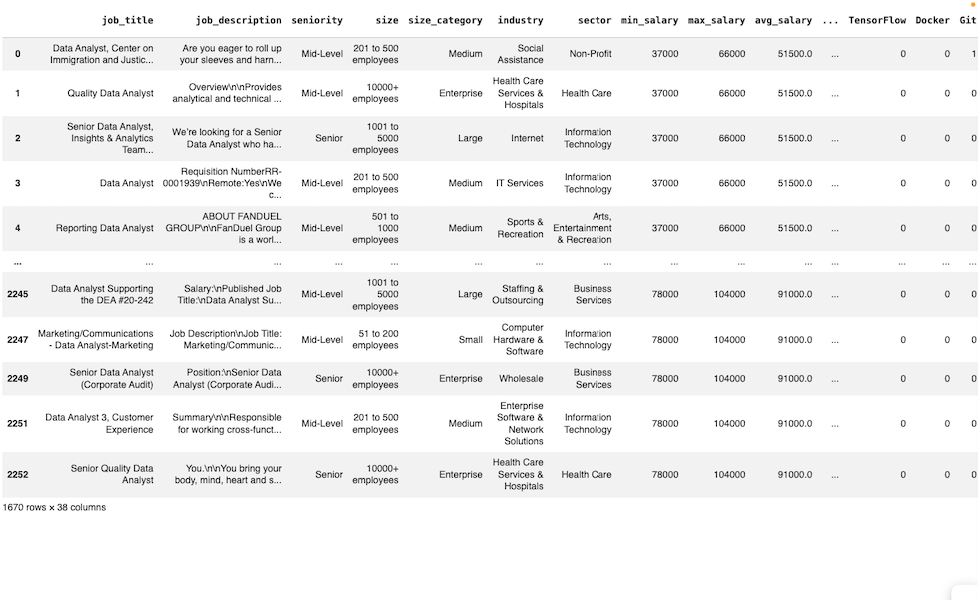

## **IV. Analysis**

### **A. Which industries have the highest demand for data analysts?**

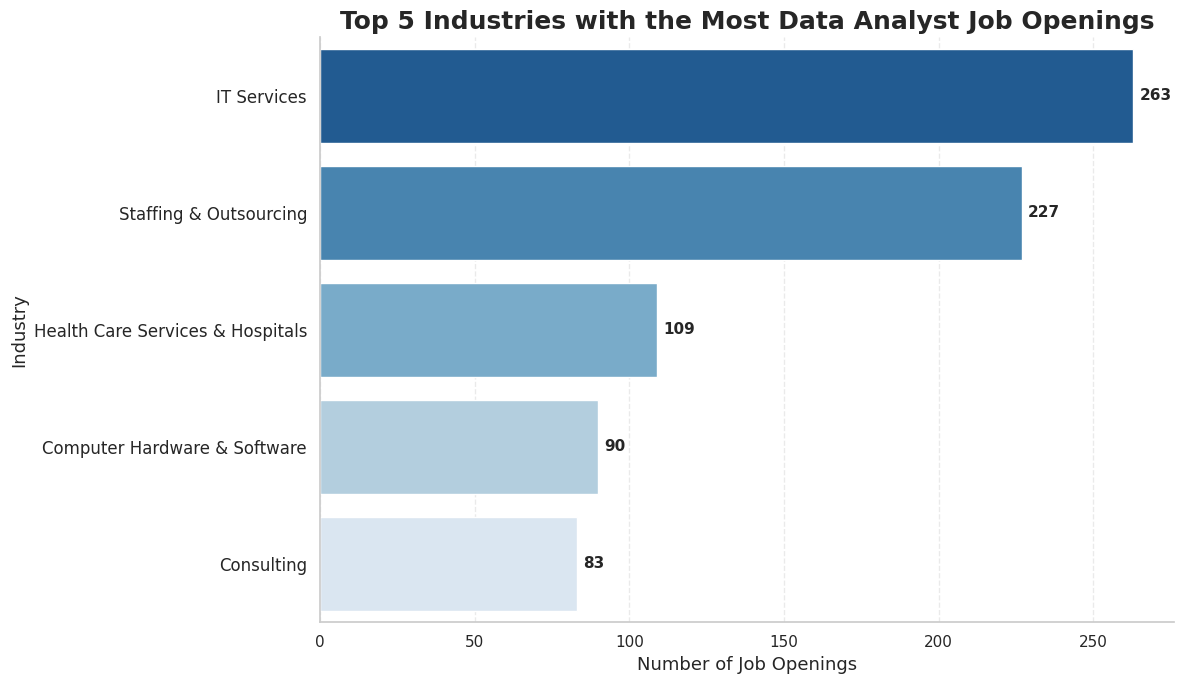

In [37]:
df_openings = df_final.groupby("industry")["job_title"].count().sort_values(ascending=False)
df_openings

,job_title
industry,
Unknown,273
IT Services,263
Staffing & Outsourcing,227
Health Care Services & Hospitals,109
Computer Hardware & Software,90
...,...
Metals Brokers,1
Preschool & Child Care,1
Sporting Goods Stores,1


In [38]:
# drop unknown row from industry column
df_openings = df_openings.drop("Unknown")
df_openings

,job_title
industry,
IT Services,263
Staffing & Outsourcing,227
Health Care Services & Hospitals,109
Computer Hardware & Software,90
Consulting,83
...,...
Metals Brokers,1
Preschool & Child Care,1
Sporting Goods Stores,1


In [39]:
# Total number of job titles
total_jobs = df_openings.sum()

# Number of IT Services job titles
it_jobs = df_openings.loc['IT Services']

# Calculate percentage
it_percentage = (it_jobs / total_jobs) * 100

print(f"IT Services job titles make up {it_percentage:.2f}% of all job titles.")

IT Services job titles make up 18.83% of all job titles.


/tmp/ipykernel_2127/1476876231.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


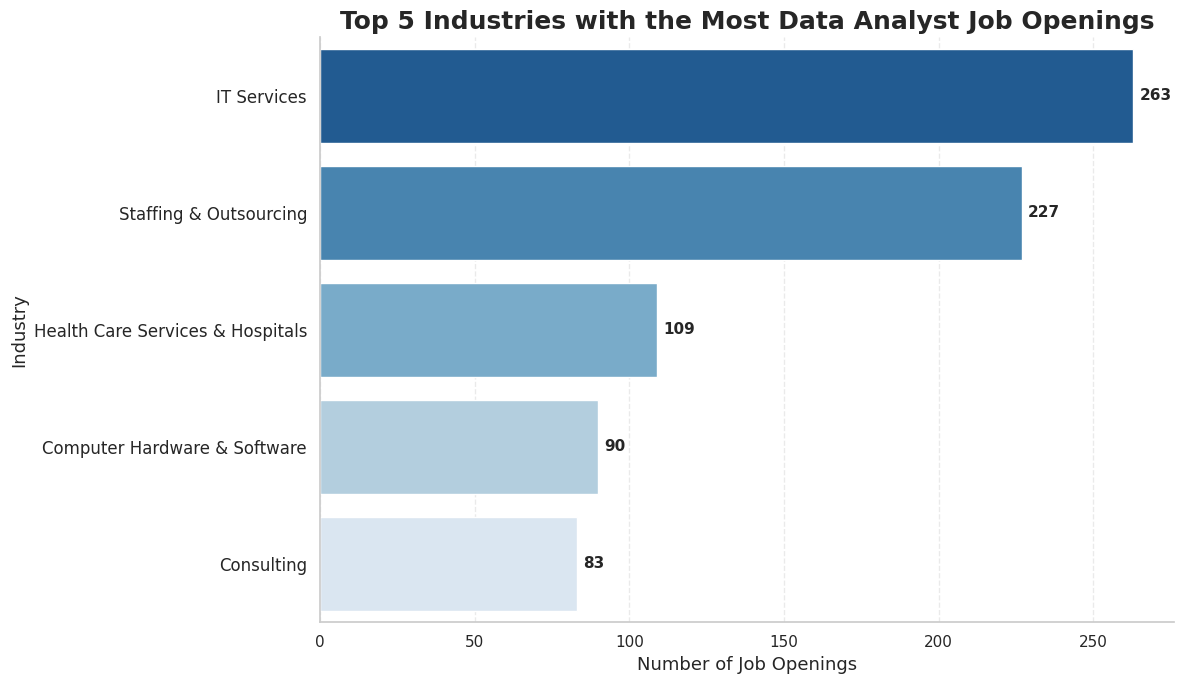

In [40]:
# Set theme
sns.set_theme(style="whitegrid")

# Get top 5 industries with most job openings
df_openings_top5 = df_openings.head(5)

# Create reversed blue palette (darkest first)
colors = sns.color_palette("Blues_r", len(df_openings_top5))

# Create figure
plt.figure(figsize=(12,7))

# Plot horizontal bar chart
ax = sns.barplot(
    x=df_openings_top5.values,
    y=df_openings_top5.index,
    palette=colors
)

# Titles and labels
plt.title("Top 5 Industries with the Most Data Analyst Job Openings", fontsize=18, weight='bold')
plt.xlabel("Number of Job Openings", fontsize=13)
plt.ylabel("Industry", fontsize=13)

# Improve tick readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)

# Add data labels
for i, value in enumerate(df_openings_top5.values):
    ax.text(
        value + 2,
        i,
        str(value),
        va='center',
        fontsize=11,
        weight='bold'
    )

# Remove extra borders
sns.despine()

# Add subtle grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

###Key Insight:
The data reveals a significant concentration of market demand within the IT Services and Staffing & Outsourcing sectors, which collectively account for nearly 50% of the total job openings among the top five industries analyzed.


### **Top 5 Skills for IT Services**

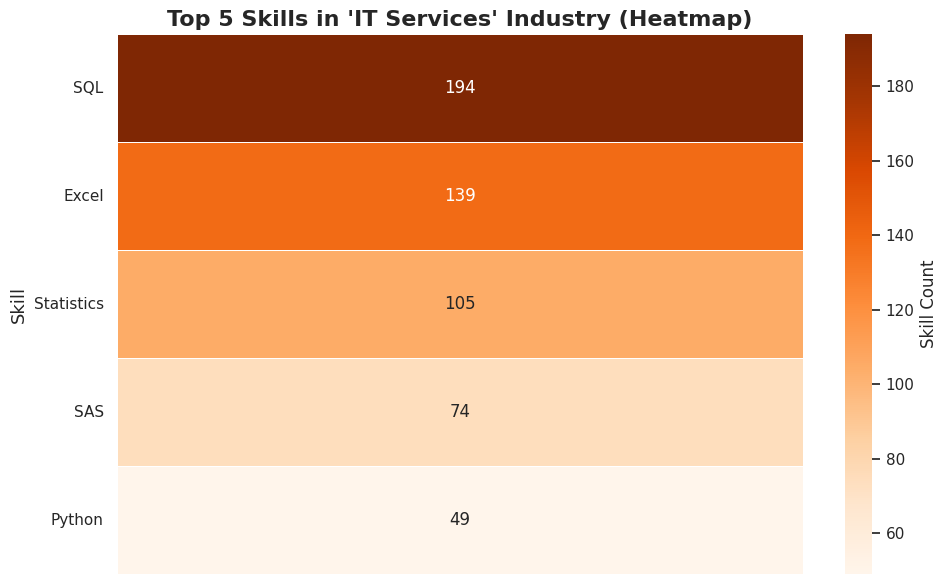

In [41]:
it_services_df = df_final[df_final['industry'] == 'IT Services']
it_services_df.head()

,job_title,job_description,seniority,years_experience,size,size_category,industry,sector,min_salary,max_salary,...,TensorFlow,Docker,Git,Hadoop,Pandas,NumPy,WPF,ASP.NET,Web API,Skill_Count
3,Data Analyst,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,Mid-Level,3.0,201 to 500 employees,Medium,IT Services,Information Technology,37000,66000,...,0,0,0,0,0,0,0,0,0,3
52,Business Data Analyst,"Summary Data Analysis, Financial Products basi...",Mid-Level,10.0,1001 to 5000 employees,Large,IT Services,Information Technology,46000,87000,...,0,0,0,0,0,0,0,0,0,3
61,Data Analyst - Data Acquisition / Data Lineage,OverviewAt Perficient you'll deliver mission-c...,Mid-Level,10.0,1001 to 5000 employees,Large,IT Services,Information Technology,51000,88000,...,0,0,0,0,0,0,0,0,0,1
62,Data Analyst - Data Scanning utilizing Rochade,OverviewAt Perficient you'll deliver mission-c...,Mid-Level,10.0,1001 to 5000 employees,Large,IT Services,Information Technology,51000,88000,...,0,0,0,0,0,0,0,0,0,1
63,Data Analyst - Stitching,OverviewAt Perficient you'll deliver mission-c...,Mid-Level,NaN,1001 to 5000 employees,Large,IT Services,Information Technology,51000,88000,...,0,0,0,0,0,0,0,0,0,0


In [42]:
def extract_skills_from_description(description, skill_patterns):
    if pd.isna(description):
        return ''
    description_lower = str(description).lower()
    found_skills = []
    for skill, patterns in skill_patterns.items():
        for pattern in patterns:
            if re.search(pattern, description_lower, re.IGNORECASE):
                found_skills.append(skill)
                break # Move to the next skill after finding one pattern
    return ', '.join(found_skills)

it_services_df['Extracted_Skills'] = it_services_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
it_services_skills = it_services_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
it_services_skills.columns = ['Skill', 'Count']

# Filter out empty strings that might result from explode() if some descriptions had no matched skills
it_services_skills_filtered = it_services_skills[it_services_skills['Skill'] != ''].reset_index(drop=True)

print("Top 5 Skills in 'IT Services' Industry:")
print(it_services_skills_filtered.head(5))

Top 5 Skills in 'IT Services' Industry:
        Skill  Count
0         SQL    194
1       Excel    139
2  Statistics    105
3         SAS     74
4      Python     49


/tmp/ipykernel_2127/1960592127.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  it_services_df['Extracted_Skills'] = it_services_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))


In [43]:
it_services_df = df_final[df_final['industry'] == 'IT Services'].copy()
it_services_df.head()

,job_title,job_description,seniority,years_experience,size,size_category,industry,sector,min_salary,max_salary,...,TensorFlow,Docker,Git,Hadoop,Pandas,NumPy,WPF,ASP.NET,Web API,Skill_Count
3,Data Analyst,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,Mid-Level,3.0,201 to 500 employees,Medium,IT Services,Information Technology,37000,66000,...,0,0,0,0,0,0,0,0,0,3
52,Business Data Analyst,"Summary Data Analysis, Financial Products basi...",Mid-Level,10.0,1001 to 5000 employees,Large,IT Services,Information Technology,46000,87000,...,0,0,0,0,0,0,0,0,0,3
61,Data Analyst - Data Acquisition / Data Lineage,OverviewAt Perficient you'll deliver mission-c...,Mid-Level,10.0,1001 to 5000 employees,Large,IT Services,Information Technology,51000,88000,...,0,0,0,0,0,0,0,0,0,1
62,Data Analyst - Data Scanning utilizing Rochade,OverviewAt Perficient you'll deliver mission-c...,Mid-Level,10.0,1001 to 5000 employees,Large,IT Services,Information Technology,51000,88000,...,0,0,0,0,0,0,0,0,0,1
63,Data Analyst - Stitching,OverviewAt Perficient you'll deliver mission-c...,Mid-Level,NaN,1001 to 5000 employees,Large,IT Services,Information Technology,51000,88000,...,0,0,0,0,0,0,0,0,0,0


In [44]:
it_services_df['Extracted_Skills'] = it_services_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
it_services_skills = it_services_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
it_services_skills.columns = ['Skill', 'Count']

# Filter out empty strings that might result from explode() if some descriptions had no matched skills
it_services_skills_filtered = it_services_skills[it_services_skills['Skill'] != ''].reset_index(drop=True)

print("Top 5 Skills in 'IT Services' Industry:")
print(it_services_skills_filtered.head(5))

Top 5 Skills in 'IT Services' Industry:
        Skill  Count
0         SQL    194
1       Excel    139
2  Statistics    105
3         SAS     74
4      Python     49


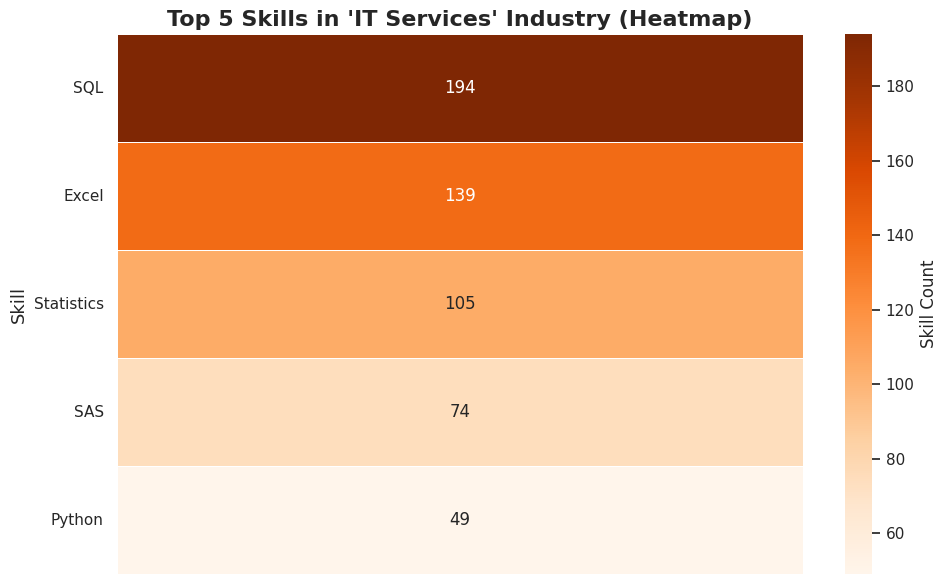

In [45]:
sns.set_theme(style="whitegrid")

# Prepare data for IT Services heatmap (top 5 skills)
it_services_top_skills_df = it_services_skills_filtered.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    it_services_top_skills_df,
    annot=True,
    fmt="d",
    cmap="Oranges", # Orange gradient
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'IT Services' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13)
plt.ylabel("Skill", fontsize=13)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Key Insights

Technical demand within the IT Services sector is characterized by a primary reliance on SQL (194) and Excel (139), which collectively serve as the foundational competencies, while Statistics, SAS(Statistical Analysis System), and Python represent a secondary tier of specialized analytical requirements.

###**Top Five Skills for 'Staffing & Outsourcing' Industry**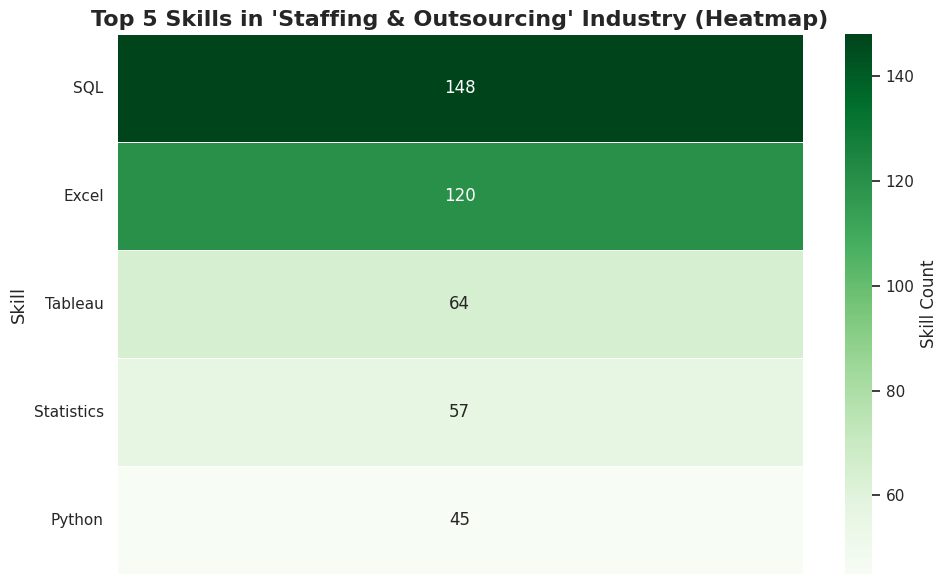


Top 5 Skills in 'Staffing & Outsourcing' Industry:
        Skill  Count
0         SQL    148
1       Excel    120
2     Tableau     64
3  Statistics     57
4      Python     45


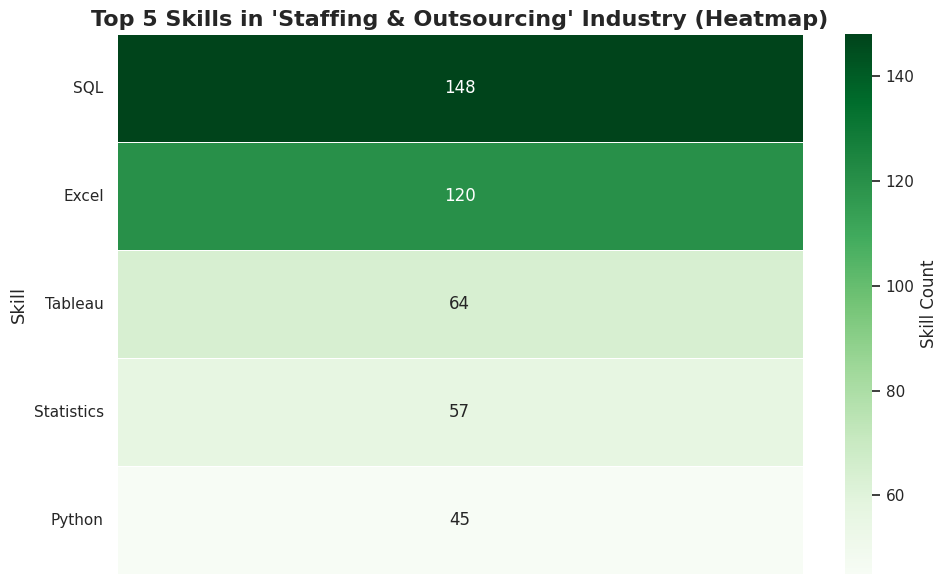

In [46]:
# Filter for 'Staffing & Outsourcing' industry
staffing_outsourcing_df = df_final[df_final['industry'] == 'Staffing & Outsourcing'].copy()

# Extract and count skills for 'Staffing & Outsourcing'
staffing_outsourcing_df.loc[:, 'Extracted_Skills'] = staffing_outsourcing_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
staffing_outsourcing_skills = staffing_outsourcing_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
staffing_outsourcing_skills.columns = ['Skill', 'Count']

# Filter out empty strings
staffing_outsourcing_skills_filtered = staffing_outsourcing_skills[staffing_outsourcing_skills['Skill'] != ''].reset_index(drop=True)

print("Top 5 Skills in 'Staffing & Outsourcing' Industry:")
print(staffing_outsourcing_skills_filtered.head(5))

sns.set_theme(style="whitegrid")

# Prepare data for Staffing & Outsourcing heatmap (top 5 skills)
staffing_outsourcing_top_skills_df = staffing_outsourcing_skills_filtered.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    staffing_outsourcing_top_skills_df,
    annot=True,
    fmt="d",
    cmap="Greens", # Using a distinct colormap
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'Staffing & Outsourcing' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13)
plt.ylabel("Skill", fontsize=13)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Key Insights
Within the Staffing & Outsourcing sector, technical demand is led by a significant concentration of SQL requirements (148), which—when combined with Excel (120)—establishes a robust baseline for data management, while visualization tools like Tableau (64) and analytical disciplines like Statistics (57) and Python (45) comprise a secondary, specialized skill tier.


### **B. Which industries offer the most accessible entry points to career pivoters?**
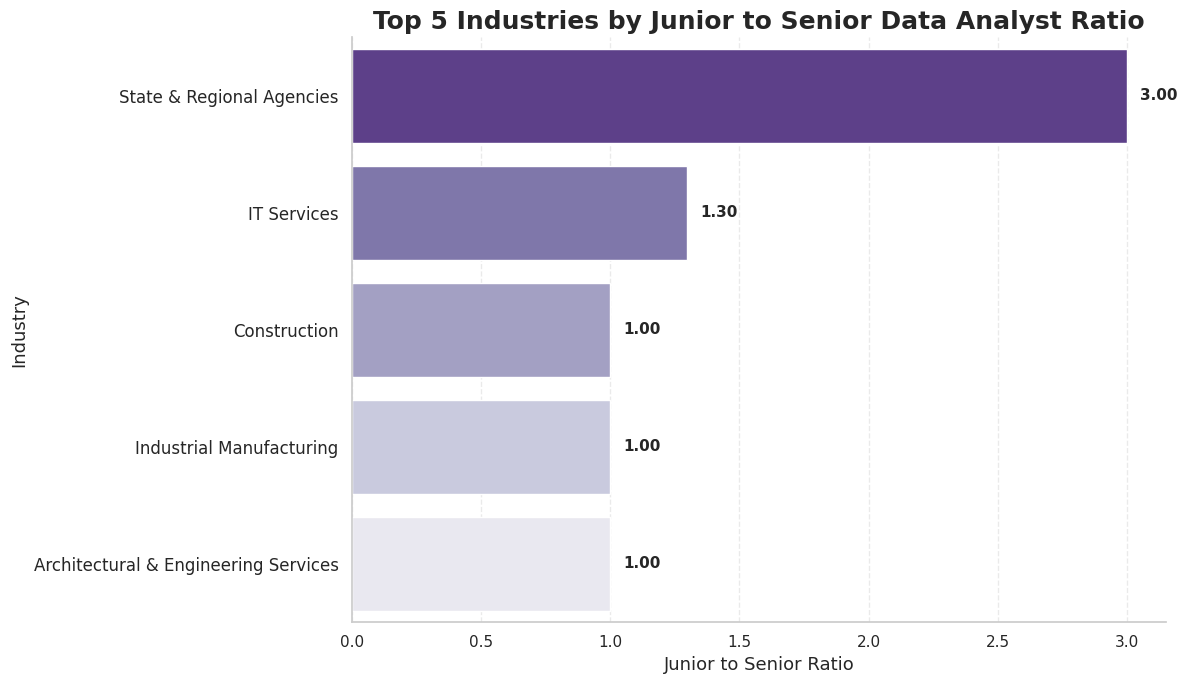

In [47]:
# Calculate the count of each seniority level per industry
industry_seniority_counts = df_final.groupby(['industry', 'seniority'])['job_title'].count().unstack(fill_value=0)

# Calculate the ratio of 'Junior' to 'Senior' positions
junior_to_senior_ratio = industry_seniority_counts['Junior'] / industry_seniority_counts['Senior']

# Handle division by zero (Infinity) cases, replace with NaN, then fill NaN with 0
junior_to_senior_ratio = junior_to_senior_ratio.replace([float('inf'), -float('inf')], pd.NA).fillna(0)

/tmp/ipykernel_2127/2523116262.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  junior_to_senior_ratio = junior_to_senior_ratio.replace([float('inf'), -float('inf')], pd.NA).fillna(0)


/tmp/ipykernel_2127/1547451471.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


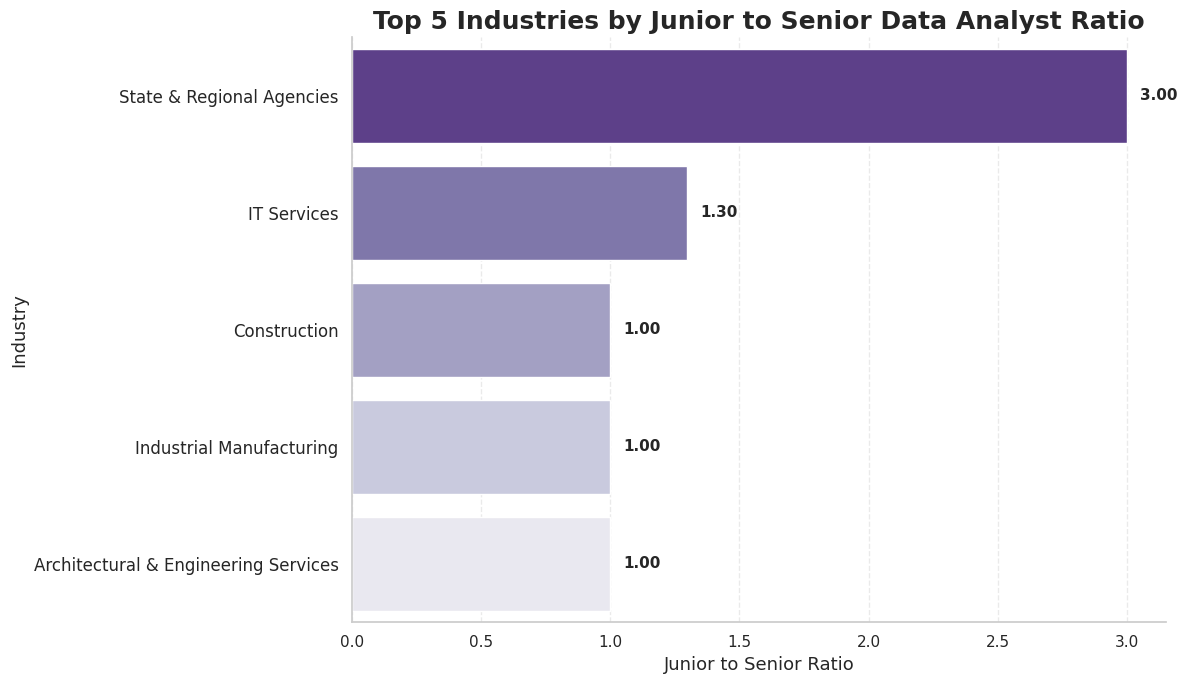

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Get top 5 industries with the highest junior to senior ratio
top5_junior_to_senior_ratio = junior_to_senior_ratio.sort_values(ascending=False).head(5)

# Create purple gradient palette (darkest for the top industry)
colors = sns.color_palette("Purples_r", len(top5_junior_to_senior_ratio))

# Create figure
plt.figure(figsize=(12, 7))

# Plot horizontal bar chart
ax = sns.barplot(
    x=top5_junior_to_senior_ratio.values,
    y=top5_junior_to_senior_ratio.index,
    palette=colors
)

# Titles and labels
plt.title("Top 5 Industries by Junior to Senior Data Analyst Ratio", fontsize=18, weight='bold')
plt.xlabel("Junior to Senior Ratio", fontsize=13)
plt.ylabel("Industry", fontsize=13)

# Improve tick readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)

# Add data labels
for i, value in enumerate(top5_junior_to_senior_ratio.values):
    ax.text(
        value + 0.05,
        i,
        f'{value:.2f}',
        va='center',
        fontsize=11,
        weight='bold'
    )

# Remove extra borders
sns.despine()

# Add subtle grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Key Insights:
State & Regional Agencies stand out as the most entry-level–friendly sector, with a junior-to-senior ratio of 3.0, meaning there are three junior roles for every senior role, while other industries remain around 1:1, indicating far fewer entry opportunities for new analysts.

### **Top 5 skills for State and Regional Agencies**

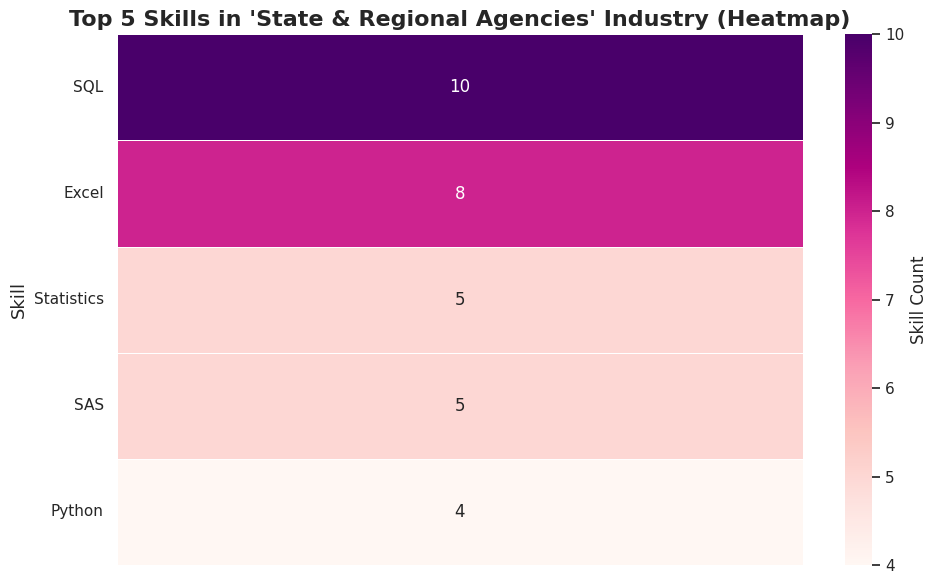

In [49]:
state_regional_agencies_df = df_final[df_final['industry'] == 'State & Regional Agencies']
state_regional_agencies_df.head()

,job_title,job_description,seniority,years_experience,size,size_category,industry,sector,min_salary,max_salary,...,TensorFlow,Docker,Git,Hadoop,Pandas,NumPy,WPF,ASP.NET,Web API,Skill_Count
1641,Junior Data Analyst,Program Specialist II perform moderate complex...,Junior,2.0,10000+ employees,Enterprise,State & Regional Agencies,Government,42000,76000,...,0,0,0,0,0,0,0,0,0,2
1644,Data Analyst I,Posting Type:\nOpen to All Applicants\n\nCateg...,Mid-Level,NaN,10000+ employees,Enterprise,State & Regional Agencies,Government,42000,76000,...,0,0,0,0,0,0,0,0,0,7
1650,Data Analyst,The Data Analyst will be part of the Departmen...,Mid-Level,NaN,10000+ employees,Enterprise,State & Regional Agencies,Government,42000,76000,...,0,0,0,0,0,0,0,0,0,5
1665,Data Analyst II,Title: FY 20-85 Data Analyst II\nDescription:\...,Mid-Level,NaN,501 to 1000 employees,Medium,State & Regional Agencies,Government,53000,104000,...,0,0,0,0,0,0,0,0,0,0
1666,Data Analyst V,"Performs complex (senior-level) data analysis,...",Mid-Level,NaN,10000+ employees,Enterprise,State & Regional Agencies,Government,53000,104000,...,0,0,0,0,0,0,0,0,0,6


In [50]:
state_regional_agencies_df.loc[:, 'Extracted_Skills'] = state_regional_agencies_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
state_regional_agencies_skills = state_regional_agencies_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
state_regional_agencies_skills.columns = ['Skill', 'Count']

# Filter out empty strings that might result from explode() if some descriptions had no matched skills
state_regional_agencies_skills_filtered = state_regional_agencies_skills[state_regional_agencies_skills['Skill'] != ''].reset_index(drop=True)

print("Top 5 Skills in 'State & Regional Agencies' Industry:")
print(state_regional_agencies_skills_filtered.head(5))

Top 5 Skills in 'State & Regional Agencies' Industry:
        Skill  Count
0         SQL     10
1       Excel      8
2  Statistics      5
3         SAS      5
4      Python      4


/tmp/ipykernel_2127/1056654107.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_regional_agencies_df.loc[:, 'Extracted_Skills'] = state_regional_agencies_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))


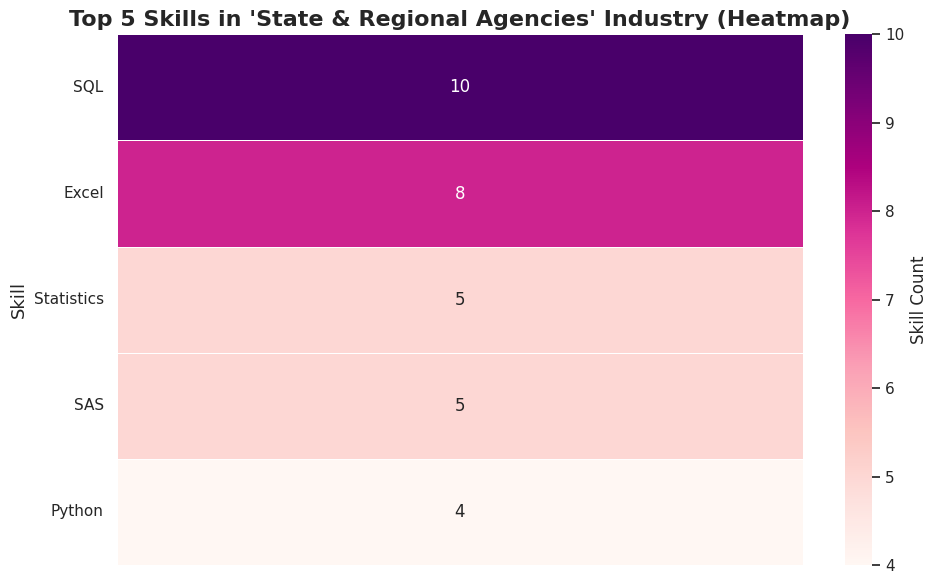

In [51]:
sns.set_theme(style="whitegrid")

# Prepare data for State & Regional Agencies heatmap (top 5 skills)
state_regional_agencies_top_skills_df = state_regional_agencies_skills_filtered.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    state_regional_agencies_top_skills_df,
    annot=True,
    fmt="d",
    cmap="RdPu", # Pink gradient
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'State & Regional Agencies' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13)
plt.ylabel("Skill", fontsize=13)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Key Insights
Technical requirements within State & Regional Agencies are anchored by a dual-dependency on SQL (10) and Excel (8), while specialized analytical competencies in Statistics, SAS, and Python represent a secondary, foundational tier of demand.

###**Top skills for 'IT Services'**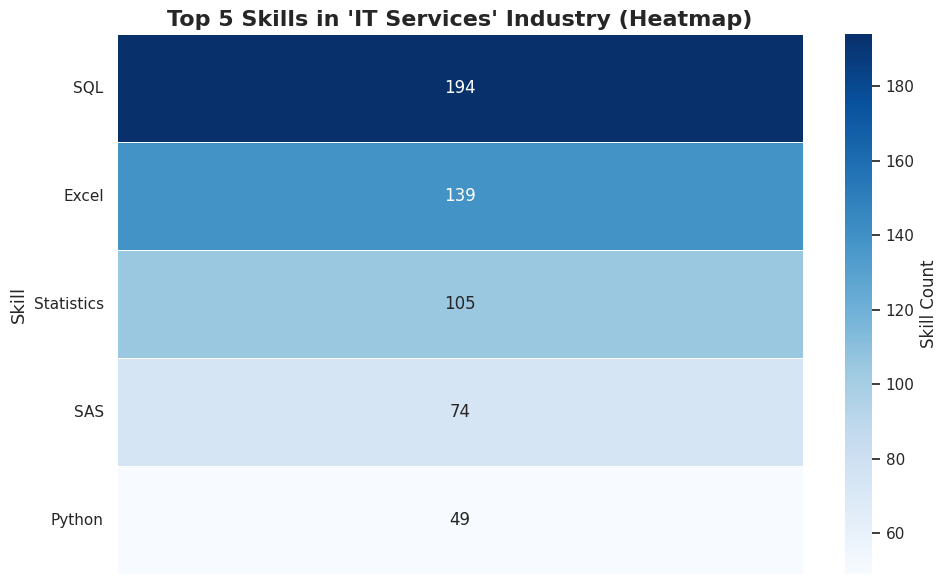

In [52]:
# Filter for 'IT Services' industry
it_services_df = df_final[df_final['industry'] == 'IT Services'].copy()

# Extract and count skills for 'IT Services'
it_services_df['Extracted_Skills'] = it_services_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
it_services_skills = it_services_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
it_services_skills.columns = ['Skill', 'Count']

print("Top 5 Skills in 'IT Services' Industry:")
print(it_services_skills.head(5))

Top 5 Skills in 'IT Services' Industry:
        Skill  Count
0         SQL    194
1       Excel    139
2  Statistics    105
3         SAS     74
4      Python     49


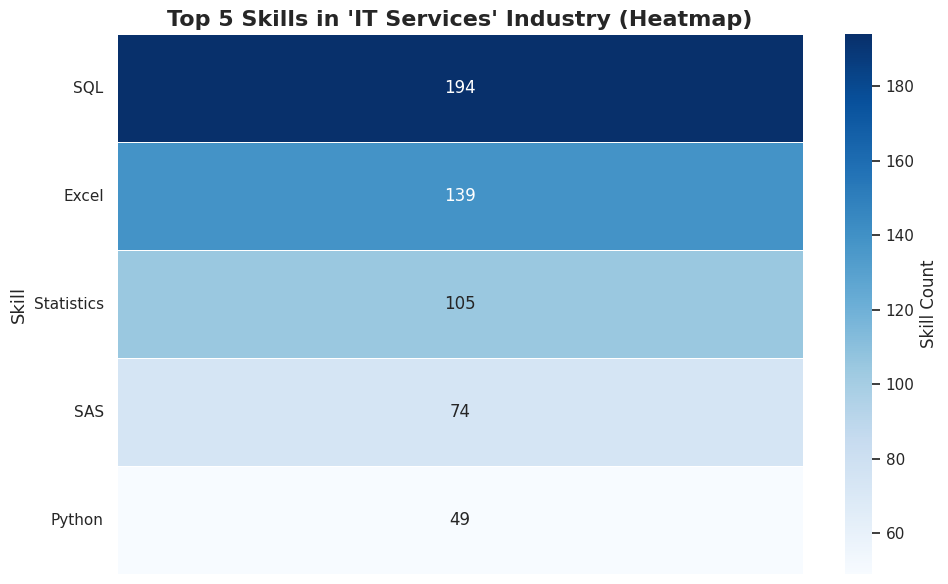

In [53]:
sns.set_theme(style="whitegrid")

# Prepare data for IT Services heatmap (top 5 skills)
it_services_top_skills_df = it_services_skills.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    it_services_top_skills_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'IT Services' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13) # No x-label needed as there's only one column
plt.ylabel("Skill", fontsize=13)
plt.xticks([]) # Hide x-axis ticks
plt.yticks(rotation=0) # Ensure skill names are horizontal
plt.tight_layout()
plt.show()

###Key Insights

Technical demand within the IT Services sector is characterized by a primary reliance on SQL (194) and Excel (139), which collectively serve as the foundational competencies, while Statistics, SAS(Statistical Analysis System), and Python represent a secondary tier of specialized analytical requirements.

### **C. What are the top five industries that have the highest average entry-level salary for data analysts?**

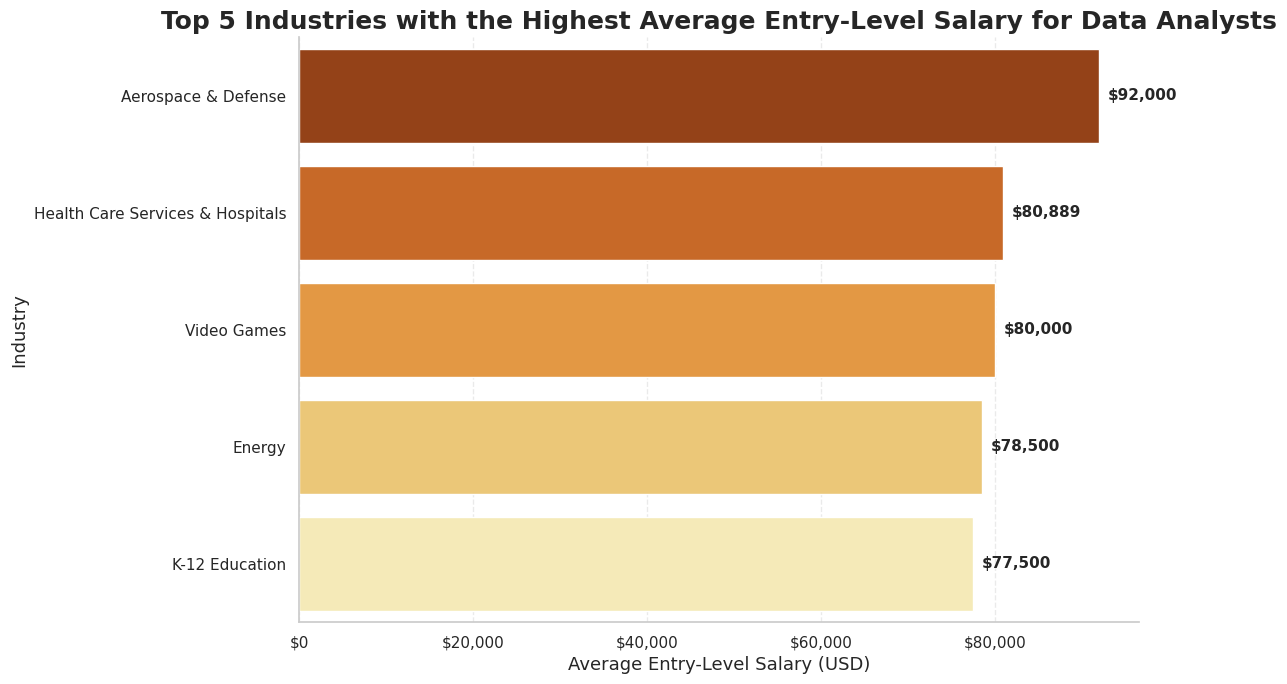

In [54]:
# Filter for Junior (entry-level) positions
df_entry = df_final[df_final["seniority"] == "Junior"].copy()

# Group by industry and calculate the mean of 'avg_salary'
df_entry_pay = df_entry.groupby("industry")["avg_salary"].mean()

# Filter out industries with 'Unknown' values
df_entry_pay_clean = df_entry_pay.drop('Unknown', errors='ignore')

df_entry_pay_clean = df_entry_pay_clean.sort_values(ascending=False)
df_entry_pay_clean

,avg_salary
industry,
Aerospace & Defense,92000.000000
Health Care Services & Hospitals,80888.888889
Video Games,80000.000000
Energy,78500.000000
K-12 Education,77500.000000
Computer Hardware & Software,74750.000000
Electrical & Electronic Manufacturing,73500.000000
Chemical Manufacturing,73000.000000
Industrial Manufacturing,73000.000000


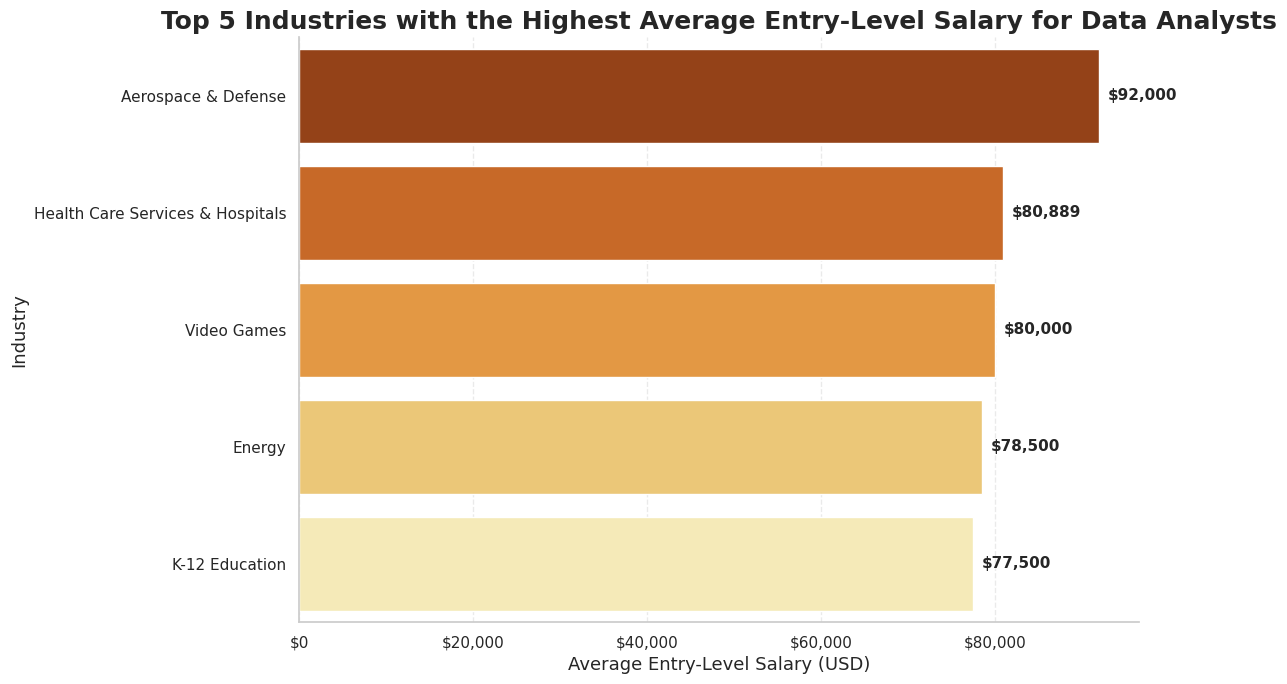

In [55]:
from matplotlib.ticker import FuncFormatter

# Filter for Junior (entry-level) positions
df_entry = df_final[df_final["seniority"] == "Junior"].copy()

# Group by industry and calculate the mean of 'avg_salary'
df_entry_pay = df_entry.groupby("industry")["avg_salary"].mean()

# Filter out industries with 'Unknown' values and sort to get top 5
df_entry_pay_clean = df_entry_pay.drop('Unknown', errors='ignore')
df_entry_pay_clean_top5 = df_entry_pay_clean.sort_values(ascending=False).head(5)

sns.set_theme(style="whitegrid")

# Create complementary color palette
colors = sns.color_palette("YlOrBr_r", len(df_entry_pay_clean_top5))

# Create figure
plt.figure(figsize=(12,7))

# Plot horizontal bar chart
ax = sns.barplot(
    x=df_entry_pay_clean_top5.values,
    y=df_entry_pay_clean_top5.index,
    hue=df_entry_pay_clean_top5.index,
    palette=colors,
    legend=False
)

# Titles and labels
plt.title("Top 5 Industries with the Highest Average Entry-Level Salary for Data Analysts", fontsize=18, weight='bold')
plt.xlabel("Average Entry-Level Salary (USD)", fontsize=13)
plt.ylabel("Industry", fontsize=13)

# Format salary axis
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add salary labels
for i, value in enumerate(df_entry_pay_clean_top5.values):
    ax.text(
        value + 1000,
        i,
        f"${value:,.0f}",
        va='center',
        fontsize=11,
        weight='bold'
    )

# Clean appearance
sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

###Key Insights
A comparative analysis of entry-level compensation reveals that Aerospace & Defense offers the highest average starting salary at \$92,000, establishing a significant premium over other top-tier sectors such as Health Care and Video Games, which cluster around the \$80,000 threshold.

###**Top five skills for 'Aerospace and Defense' Industry**
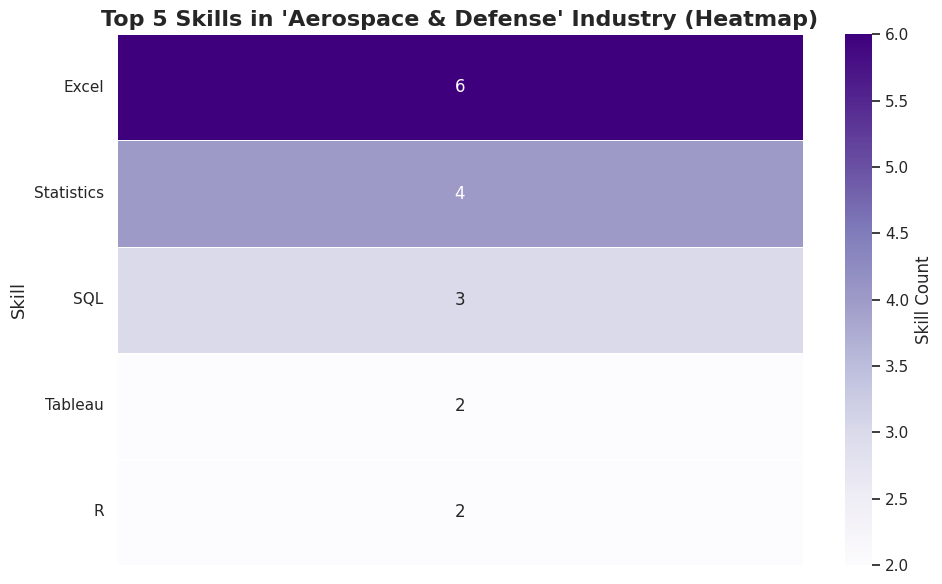

Top 5 Skills in 'Aerospace & Defense' Industry:
        Skill  Count
0       Excel      6
1  Statistics      4
2         SQL      3
3     Tableau      2
4           R      2


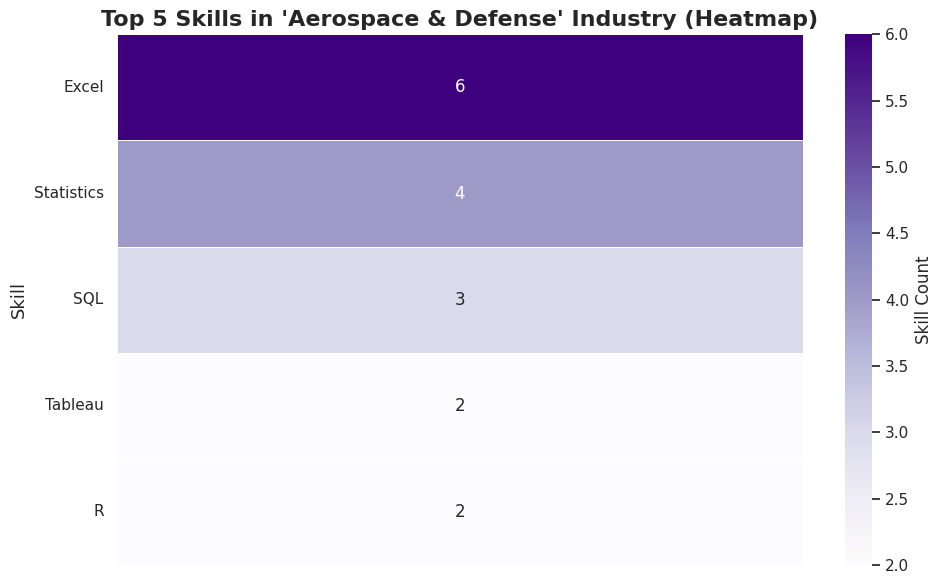

In [56]:
# Filter for 'Aerospace & Defense' industry
aerospace_defense_df = df_final[df_final['industry'] == 'Aerospace & Defense'].copy()

# Extract and count skills for 'Aerospace & Defense'
aerospace_defense_df.loc[:, 'Extracted_Skills'] = aerospace_defense_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
aerospace_defense_skills = aerospace_defense_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
aerospace_defense_skills.columns = ['Skill', 'Count']

# Filter out empty strings that might result from explode() if some descriptions had no matched skills
aerospace_defense_skills_filtered = aerospace_defense_skills[aerospace_defense_skills['Skill'] != ''].reset_index(drop=True)

print("Top 5 Skills in 'Aerospace & Defense' Industry:")
print(aerospace_defense_skills_filtered.head(5))

sns.set_theme(style="whitegrid")

# Prepare data for Aerospace & Defense heatmap (top 5 skills)
aerospace_defense_top_skills_df = aerospace_defense_skills_filtered.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    aerospace_defense_top_skills_df,
    annot=True,
    fmt="d",
    cmap="Purples", # Using a distinct colormap
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'Aerospace & Defense' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13)
plt.ylabel("Skill", fontsize=13)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Key Insights

Excel dominates as the most in-demand skill in the Aerospace & Defense industry (n=6), followed by Statistics (n=4) and SQL (n=3), while Tableau and R trail significantly at n=2 each, suggesting that foundational data management and analytical tools are prioritized over advanced visualization and programming capabilities in this sector.

###**Top Five Skills for 'Health Care Services & Hospitals' Industry**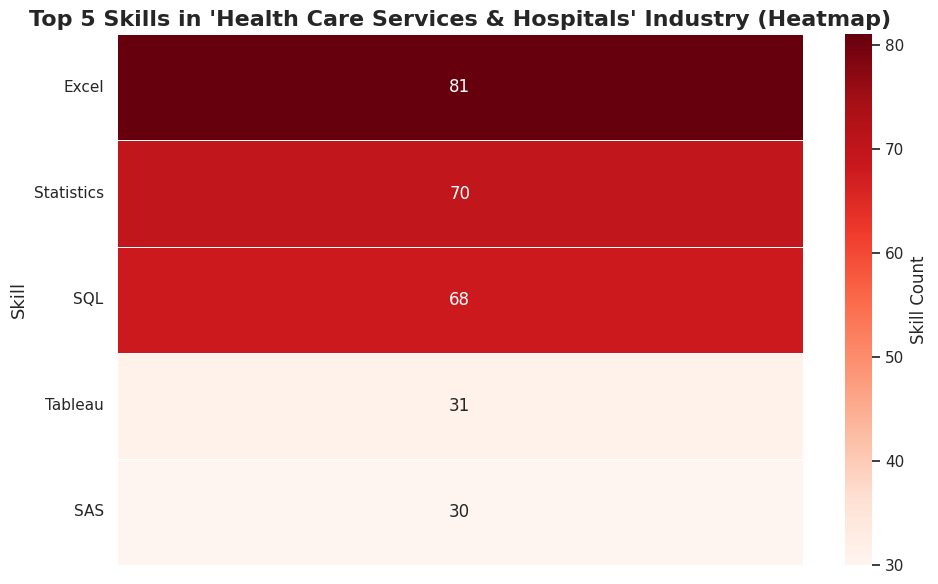

Top 5 Skills in 'Health Care Services & Hospitals' Industry:
        Skill  Count
0       Excel     81
1  Statistics     70
2         SQL     68
3     Tableau     31
4         SAS     30


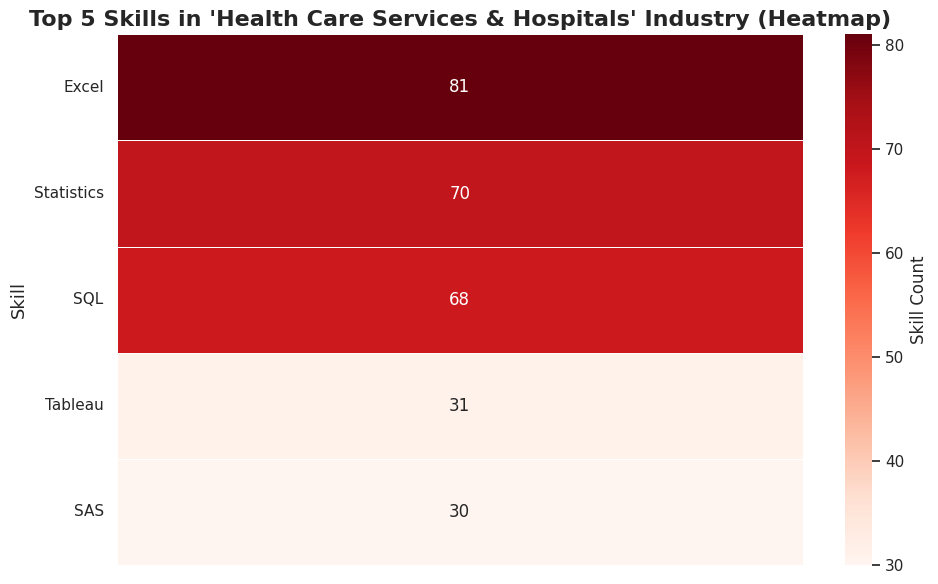

In [57]:
# Filter for 'Health Care Services & Hospitals' industry
healthcare_df = df_final[df_final['industry'] == 'Health Care Services & Hospitals'].copy()

# Extract and count skills for 'Health Care Services & Hospitals'
healthcare_df.loc[:, 'Extracted_Skills'] = healthcare_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
healthcare_skills = healthcare_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
healthcare_skills.columns = ['Skill', 'Count']

# Filter out empty strings that might result from explode() if some descriptions had no matched skills
healthcare_skills_filtered = healthcare_skills[healthcare_skills['Skill'] != ''].reset_index(drop=True)

print("Top 5 Skills in 'Health Care Services & Hospitals' Industry:")
print(healthcare_skills_filtered.head(5))

sns.set_theme(style="whitegrid")

# Prepare data for Health Care Services & Hospitals heatmap (top 5 skills)
healthcare_top_skills_df = healthcare_skills_filtered.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    healthcare_top_skills_df,
    annot=True,
    fmt="d",
    cmap="Reds", # Using a distinct colormap
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'Health Care Services & Hospitals' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13)
plt.ylabel("Skill", fontsize=13)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Key Insights

Technical demand within the Aerospace & Defense sector is primarily centered on Excel (6) and Statistics (4), reflecting a specialized emphasis on rigorous mathematical validation and spreadsheet-based modeling over common database or visualization frameworks.

### **D. Which of these industries have the strongest long-term salary growth?**

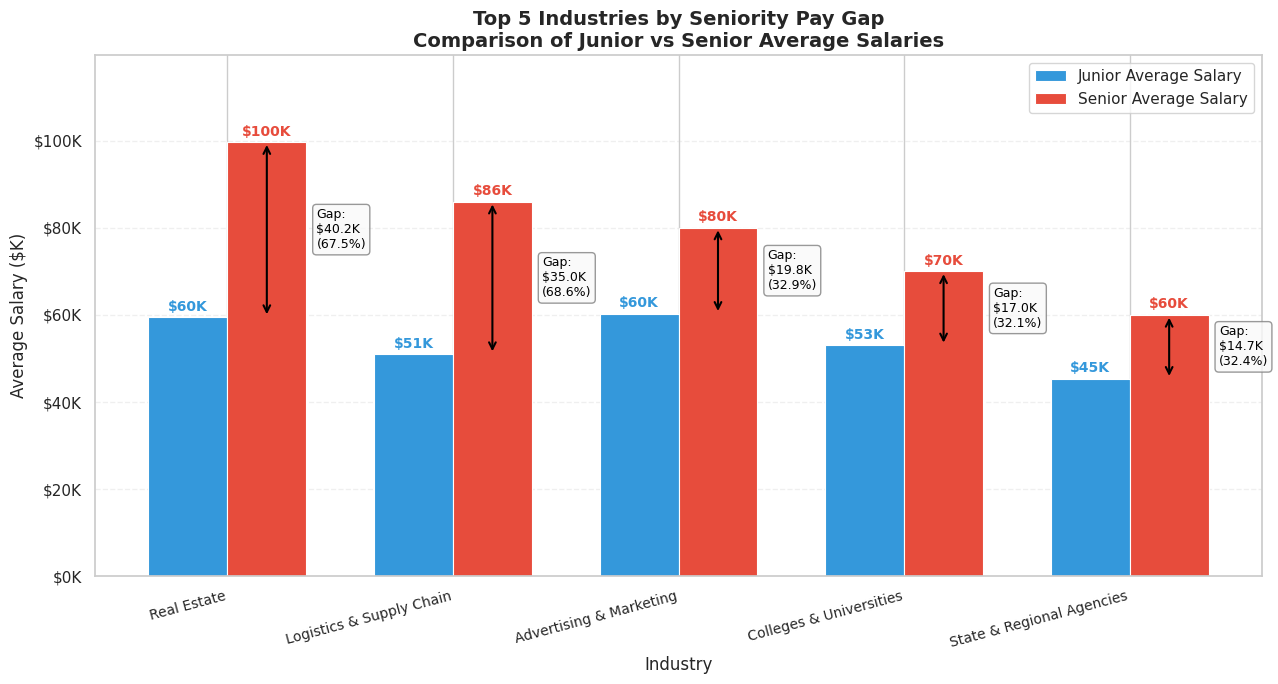

In [58]:
df_senior_pay = df_final[df_final["seniority"]=="Senior"].groupby("industry")["avg_salary"].mean()
df_junior_pay = df_final[df_final["seniority"]=="Junior"].groupby("industry")["avg_salary"].mean()

df_pay_gap = df_senior_pay - df_junior_pay
df_pay_gap = df_pay_gap.sort_values(ascending=False)

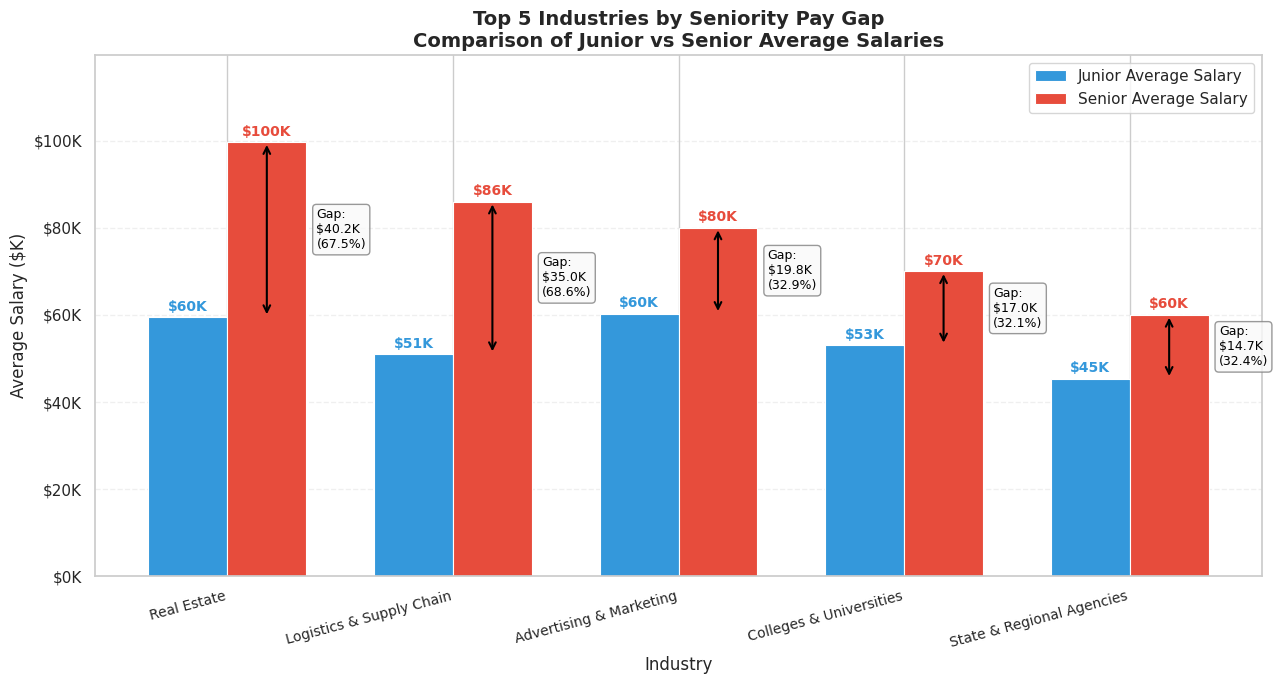

In [59]:
# ── Set up the grouped bar chart ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Define df_pay_gap (assuming df_junior_pay and df_senior_pay are defined)
df_pay_gap = df_senior_pay - df_junior_pay

# Define df_pay_gap_clean_top5 by getting the top 5 industries with the highest pay gap
df_pay_gap_clean_top5 = df_pay_gap.sort_values(ascending=False).head(5)

# Create a DataFrame for top5_gap if it doesn't exist already
# (Assuming df_pay_gap_clean and df_junior_pay/df_senior_pay are defined in previous cells)
top5_gap = pd.DataFrame({
    'Pay_Gap_K': df_pay_gap_clean_top5 / 1000,
    'Junior_K': df_junior_pay.loc[df_pay_gap_clean_top5.index] / 1000,
    'Senior_K': df_senior_pay.loc[df_pay_gap_clean_top5.index] / 1000
})
top5_gap['Growth_%'] = (top5_gap['Pay_Gap_K'] / top5_gap['Junior_K']) * 100

industries  = top5_gap.index.tolist()
junior_vals = top5_gap['Junior_K'].values
senior_vals = top5_gap['Senior_K'].values
gap_vals    = top5_gap['Pay_Gap_K'].values
growth_pct  = top5_gap['Growth_%'].values # New variable for percentage growth

x     = np.arange(len(industries))  # position of each industry group
width = 0.35                         # width of each bar

fig, ax = plt.subplots(figsize=(13, 7))

# ── Draw the two bars side by side ───────────────────────────────────────────
bars_junior = ax.bar(x - width/2, junior_vals, width,
                     label='Junior Average Salary',
                     color='#3498db', edgecolor='white', linewidth=0.8)

bars_senior = ax.bar(x + width/2, senior_vals, width,
                     label='Senior Average Salary',
                     color='#e74c3c', edgecolor='white', linewidth=0.8)

# ── Add salary labels on top of each bar ─────────────────────────────────────
for bar in bars_junior:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.8,
            f'${height:.0f}K', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#3498db')

for bar in bars_senior:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.8,
            f'${height:.0f}K', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#e74c3c')

# ── Add pay gap annotation between bars ──────────────────────────────────────
for i, (j_val, s_val, gap, pct) in enumerate(zip(junior_vals, senior_vals, gap_vals, growth_pct)):
    mid_y = (j_val + s_val) / 2
    ax.annotate('',
                xy=(x[i] + width/2, s_val),
                xytext=(x[i] + width/2, j_val),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(x[i] + width/2 + 0.22, mid_y,
            f'Gap:\n${gap:.1f}K\n({pct:.1f}%)', ha='left', va='center',
            fontsize=9, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9f9f9',
                      edgecolor='gray', alpha=0.8))

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xlabel('Industry', fontsize=12)
ax.set_ylabel('Average Salary ($K)', fontsize=12)
ax.set_title('Top 5 Industries by Seniority Pay Gap\n'
             'Comparison of Junior vs Senior Average Salaries',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(industries, rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, max(senior_vals) * 1.2)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f'${val:.0f}K'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('top5_seniority_gap_full.png', bbox_inches='tight', dpi=150)
plt.show()

In [60]:
# Get the top 5 industries with the highest seniority pay gap
top5_industries = df_pay_gap.sort_values(ascending=False).head(5).index.tolist()

# Filter the original dataframe for those industries
top5_df = df_final[df_final['industry'].isin(top5_industries)].copy()

# Calculate the average years of experience for each industry
avg_experience = top5_df.groupby('industry')['years_experience'].mean().sort_values(ascending=False)

avg_experience

,years_experience
industry,
Colleges & Universities,5.769231
Advertising & Marketing,5.250000
Logistics & Supply Chain,3.333333
State & Regional Agencies,3.000000
Real Estate,2.571429


In [61]:
df_pay_gap

,avg_salary
industry,
Accounting,NaN
Advertising & Marketing,19812.500000
Aerospace & Defense,-44500.000000
Architectural & Engineering Services,0.000000
Automotive Parts & Accessories Stores,NaN
Banks & Credit Unions,13375.000000
Beauty & Personal Accessories Stores,NaN
Biotech & Pharmaceuticals,NaN
Brokerage Services,NaN


In [62]:
avg_experience_df = (
    df_final[df_final['industry'].isin(top5_industries)]
    .groupby('industry')['years_experience']
    .mean()
    .reset_index(name='average_years_experience')
)

avg_experience_df

,industry,average_years_experience
0,Advertising & Marketing,5.250000
1,Colleges & Universities,5.769231
2,Logistics & Supply Chain,3.333333
3,Real Estate,2.571429
4,State & Regional Agencies,3.000000


In [63]:
merged_df = pd.merge(df_pay_gap, avg_experience_df, on='industry', how='left')

merged_df

,industry,avg_salary,average_years_experience
0,Accounting,NaN,NaN
1,Advertising & Marketing,19812.500000,5.250000
2,Aerospace & Defense,-44500.000000,NaN
3,Architectural & Engineering Services,0.000000,NaN
4,Automotive Parts & Accessories Stores,NaN,NaN
5,Banks & Credit Unions,13375.000000,NaN
6,Beauty & Personal Accessories Stores,NaN,NaN
7,Biotech & Pharmaceuticals,NaN,NaN
8,Brokerage Services,NaN,NaN
9,"Cable, Internet & Telephone Providers",NaN,NaN


/tmp/ipykernel_2127/2404169033.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


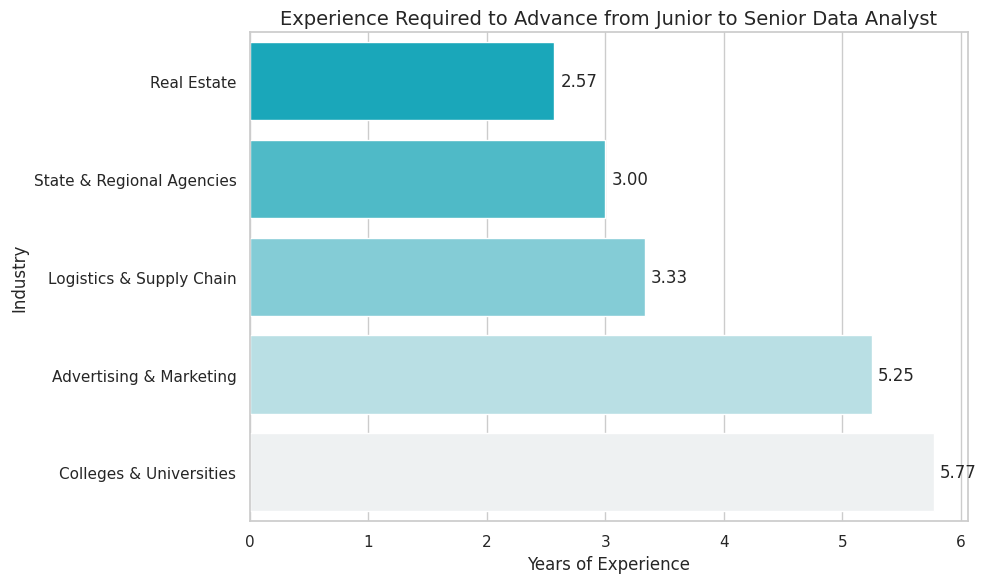

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Get the industry names of the top 5 industries based on salary gap
top5_industry_names = df_pay_gap.sort_values(ascending=False).head(5).index.tolist()

# Filter merged_df to get data for these top 5 industries
plot_data = merged_df[merged_df['industry'].isin(top5_industry_names)].copy()

# Sort for better horizontal plotting by average_years_experience
plot_data = plot_data.sort_values(by="average_years_experience", ascending=True)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_data,
    x="average_years_experience",
    y="industry",
    palette=sns.light_palette("#00bcd4", n_colors=len(plot_data))[::-1]  # inverted cyan shades
)

# Add value labels
for i, v in enumerate(plot_data["average_years_experience"]):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center")

plt.title("Experience Required to Advance from Junior to Senior Data Analyst", fontsize=14)
plt.xlabel("Years of Experience")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

In [72]:
# Filter for 'Real Estate' industry
real_estate_df = df_final[df_final['industry'] == 'Real Estate'].copy()

# Extract and count skills for 'Real Estate'
real_estate_df.loc[:, 'Extracted_Skills'] = real_estate_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
real_estate_skills = real_estate_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
real_estate_skills.columns = ['Skill', 'Count']

print("Top 5 Skills in 'Real Estate' Industry:")
print(real_estate_skills.head(5))

Top 5 Skills in 'Real Estate' Industry:
        Skill  Count
0         SQL      9
1       Excel      9
2     Tableau      8
3      Python      7
4  Statistics      6


In [66]:
# Filter for 'Real Estate' industry
logistics_df = df_final[df_final['industry'] == 'Logistics & Supply Chain'].copy()

# Extract and count skills for 'Real Estate'
logistics_df.loc[:, 'Extracted_Skills'] = logistics_df['job_description'].apply(lambda x: extract_skills_from_description(x, SKILL_PATTERNS))
logistics_skills = logistics_df['Extracted_Skills'].str.split(', ').explode().value_counts().reset_index()
logistics_skills.columns = ['Skill', 'Count']

print("Top 5 Skills in 'Logistics & Supply Chain' Industry:")
print(logistics_skills.head(5))

Top 5 Skills in 'Logistics & Supply Chain' Industry:
        Skill  Count
0       Excel      8
1         SQL      7
2      Python      6
3           R      4
4  Statistics      3


### Key Insights
**Real Estate and Logistics & Supply Chain** **show the largest salary growth**, with senior roles paying about **67–69%** more than junior roles. In contrast, State & Regional Agencies and Colleges & Universities have smaller pay increases, suggesting weaker long-term salary growth. This indicates that industry choice strongly affects long-term earning potential.

###**Top Five Skills for 'Real Estate Industry'**
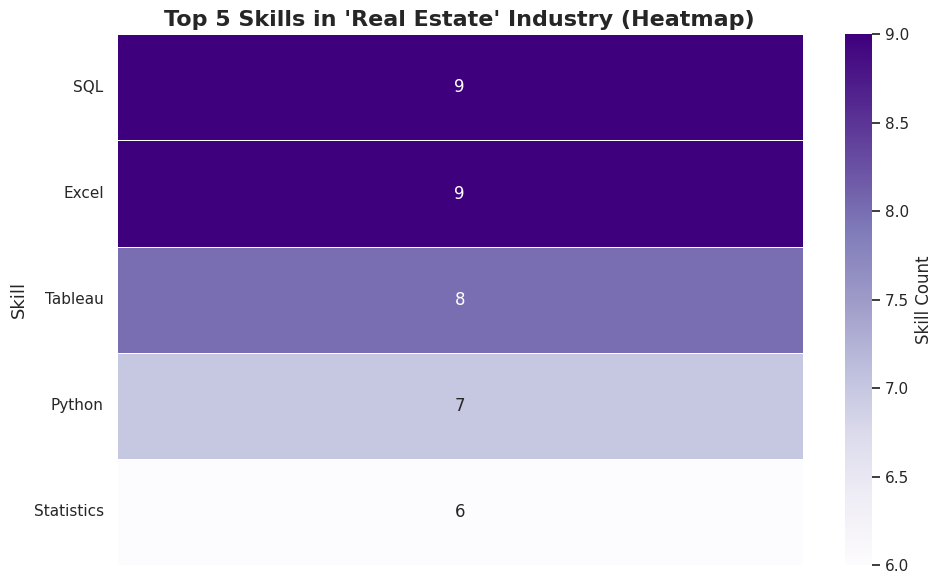

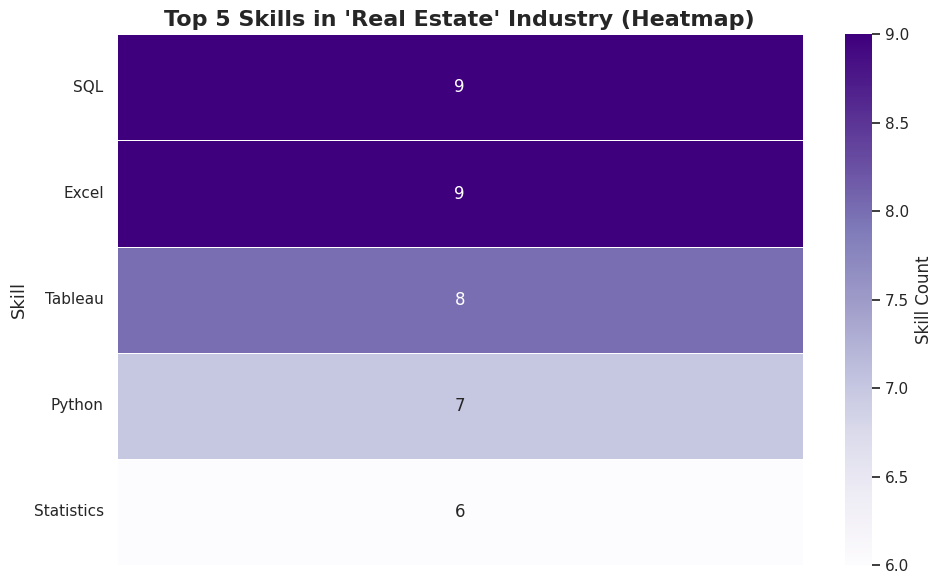

In [67]:
sns.set_theme(style="whitegrid")

# Prepare data for Real Estate heatmap (top 5 skills)
real_estate_top_skills_df = real_estate_skills.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    real_estate_top_skills_df,
    annot=True,
    fmt="d",
    cmap="Purples", # Using a distinct colormap
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'Real Estate' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13)
plt.ylabel("Skill", fontsize=13)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Key Insight
The Real Estate industry shows a strong demand for data management and reporting skills, with SQL and Excel appearing most frequently among job listings. Visualization tools like Tableau are also commonly required, highlighting the importance of presenting property and market data effectively. Python and Statistics appear slightly less often but still play a supporting role in performing deeper data analysis. Overall, the industry prioritizes professionals who can manage datasets, analyze market trends, and communicate insights through dashboards and reports.

### **Top 5 Skills for 'Logistics & Supply Chain' Industry**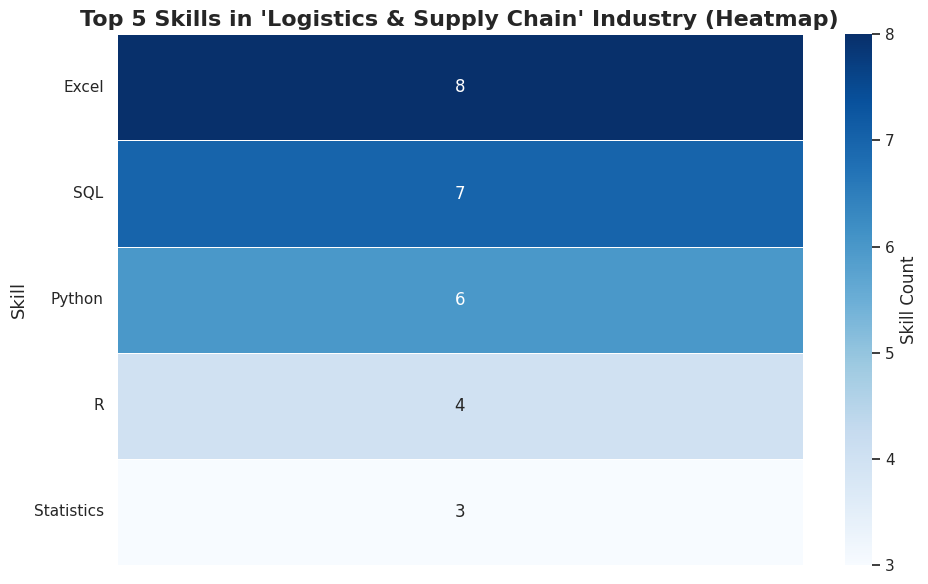


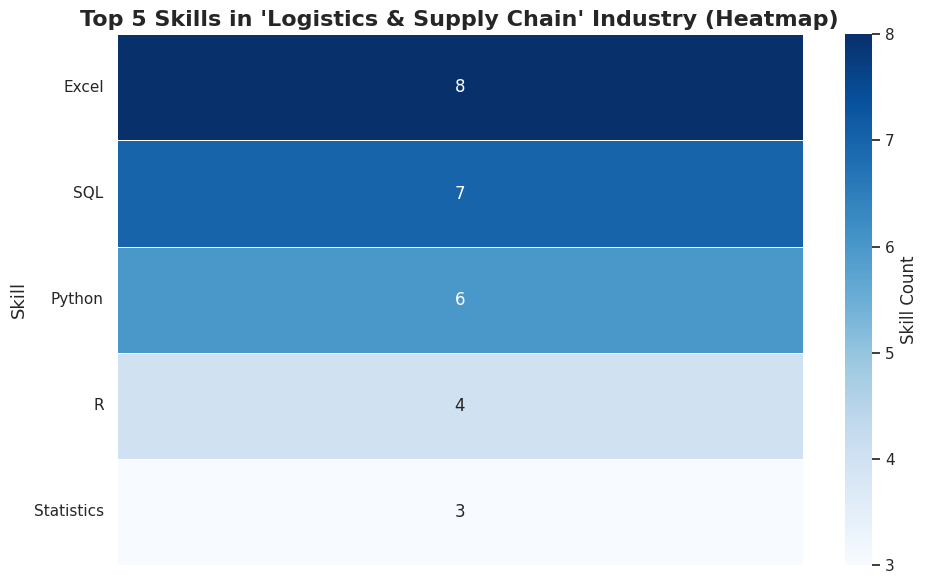

In [68]:
sns.set_theme(style="whitegrid")

# Prepare data for Logistics & Supply Chain heatmap (top 5 skills)
logistics_top_skills_df = logistics_skills.head(5).set_index('Skill')

plt.figure(figsize=(10, 6))
sns.heatmap(
    logistics_top_skills_df,
    annot=True,
    fmt="d",
    cmap="Blues", # Using a distinct colormap
    linewidths=.5,
    cbar_kws={'label': 'Skill Count'}
)

plt.title("Top 5 Skills in 'Logistics & Supply Chain' Industry (Heatmap)", fontsize=16, weight='bold')
plt.xlabel("", fontsize=13)
plt.ylabel("Skill", fontsize=13)
plt.xticks([])
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Key Insight
In the Logistics & Supply Chain industry, Excel and SQL dominate the skill requirements, reflecting the industry's reliance on structured data management and operational reporting. Python also appears frequently, indicating the growing use of automation and data processing in supply chain analytics. Unlike Real Estate, R appears among the top skills, suggesting a stronger emphasis on statistical modeling and forecasting. Overall, the industry values analysts who can optimize operations, analyze logistics data, and support decision-making through quantitative methods.

### **Experience Required to Advance from Junior to Senior Data Analyst**

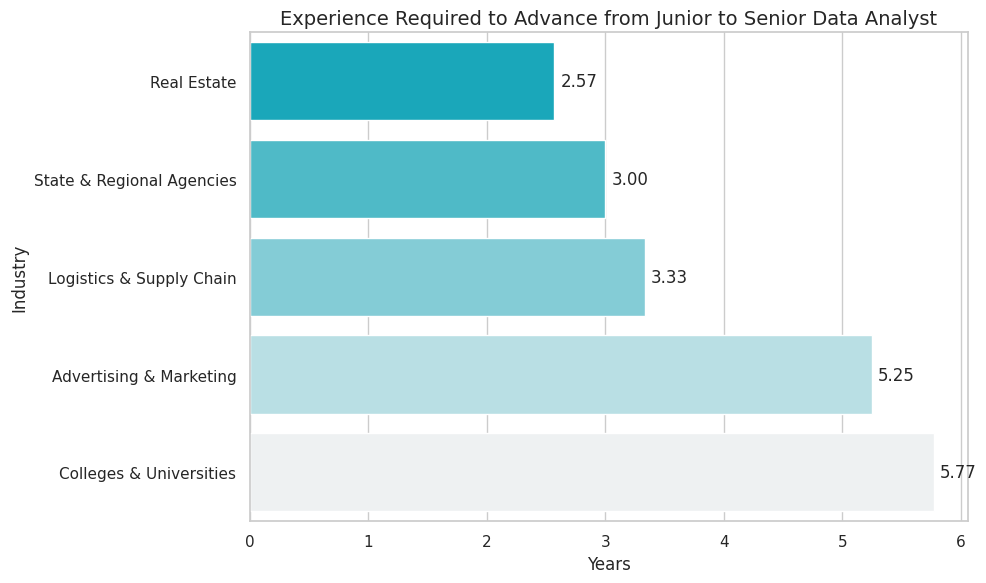

### Key Insights
Promotion timelines vary across industries. **Real Estate and State & Regional Agencies** **require the least experience** **(around 2.6–3 years)** to reach senior roles, while Advertising & Marketing and Colleges & Universities require over 5 years. This suggests some industries allow faster career progression for new analysts.

## **V. Conclusion**

This study examined job availability, skill requirements, and salary trends for data analysts across various industries in order to better understand the factors that shape career opportunities within the field.

The findings indicate that the IT Services industry represents the largest share of job openings, accounting for 18.83% of postings, suggesting that it currently offers the most accessible entry point for aspiring data analysts. In terms of entry-level compensation, the Aerospace & Defense industry provides the highest average starting salary, reaching approximately $92,000 annually, highlighting strong financial incentives for analysts entering this sector.

While starting salaries vary across industries, long-term earning potential also differs significantly. The analysis revealed that the Real Estate industry exhibits the largest seniority pay gap, with salaries increasing by an average of 67.5% from junior to senior roles, indicating substantial opportunities for salary growth over time.

### **From 25 Skills to 6 — The Essential Toolkit for Breaking Into Data Analytics**
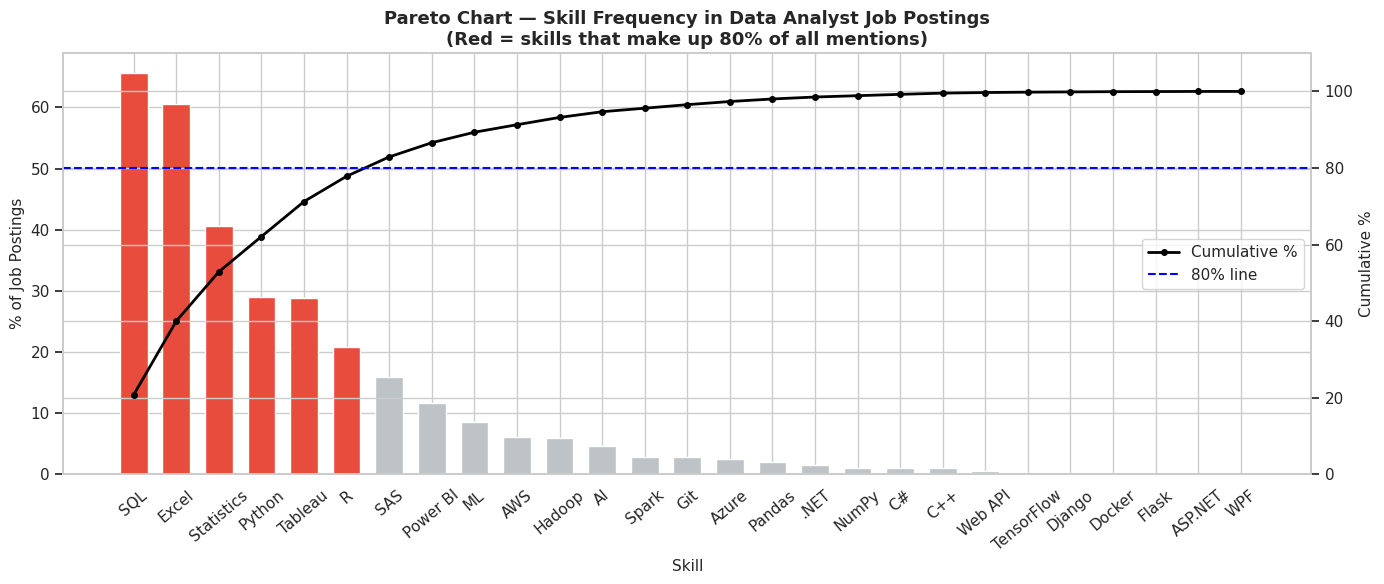

In addition to industry trends, the analysis of skill requirements reveals that employers consistently prioritize a core set of technical competencies. The Pareto analysis demonstrates that a small group of key skills accounts for the majority of skill mentions in job postings, with SQL, Excel, Statistics, Python, Tableau, and R collectively representing roughly 80% of all required skills. This finding suggests that proficiency in these foundational tools is essential for individuals pursuing a career in data analytics.

Overall, the results suggest that aspiring data analysts can enhance their career prospects by developing strong analytical and technical capabilities while also considering industry-specific demand and long-term salary progression. Understanding these trends can help individuals make more informed decisions regarding skill development and career specialization within the data analytics profession.

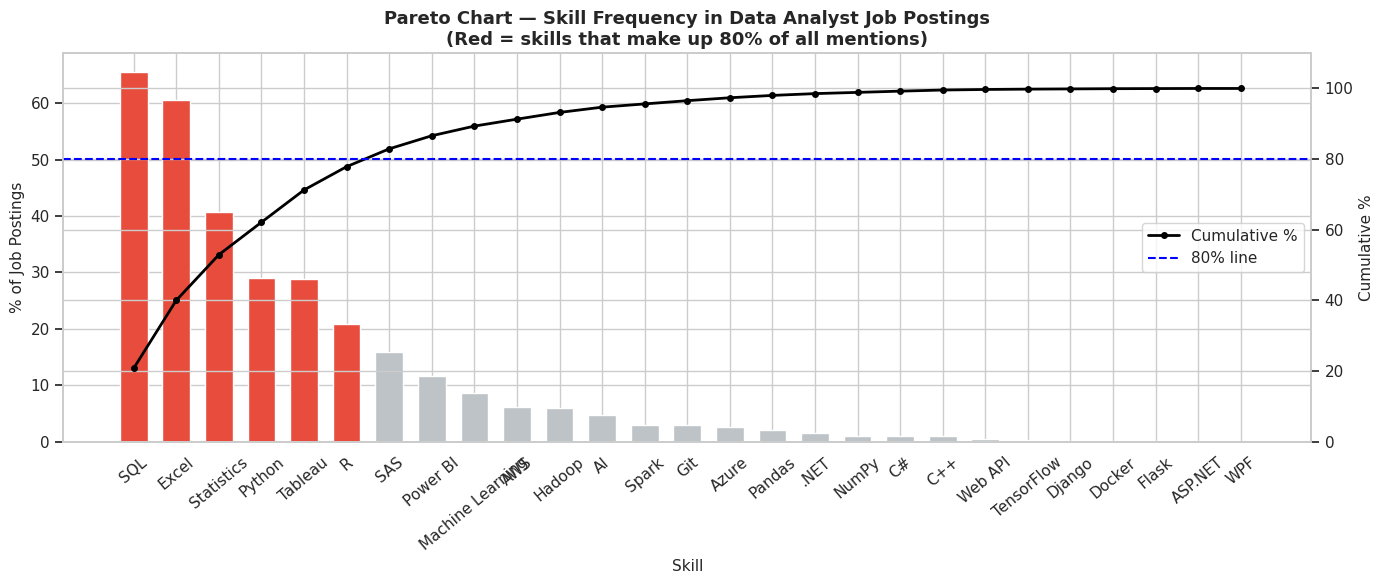

📌 Skills that account for 80% of all mentions:
----------------------------------------
   SQL                 :  65.6%  cumulative: 20.8% ✅ (within 80%)
   Excel               :  60.6%  cumulative: 40.0% ✅ (within 80%)
   Statistics          :  40.7%  cumulative: 52.9% ✅ (within 80%)
   Python              :  29.0%  cumulative: 62.1% ✅ (within 80%)
   Tableau             :  28.8%  cumulative: 71.3% ✅ (within 80%)
   R                   :  20.8%  cumulative: 77.9% ✅ (within 80%)
   SAS                 :  15.9%  cumulative: 82.9%
   Power BI            :  11.7%  cumulative: 86.6%
   Machine Learning    :   8.6%  cumulative: 89.3%
   AWS                 :   6.2%  cumulative: 91.3%
   Hadoop              :   6.0%  cumulative: 93.2%
   AI                  :   4.7%  cumulative: 94.7%
   Spark               :   2.9%  cumulative: 95.6%
   Git                 :   2.9%  cumulative: 96.5%
   Azure               :   2.6%  cumulative: 97.4%
   Pandas              :   2.1%  cumulative: 98.0%
   .NE

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# ── SIMPLE PARETO: Which skills appear most in job postings? ──────────────────
skill_counts  = df_final[SKILLS].sum().sort_values(ascending=False)
skill_pct     = (skill_counts / len(df_final) * 100).round(1)
cumulative    = skill_pct.cumsum() / skill_pct.sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars — red if within 80%, gray if beyond
colors = ['#e74c3c' if c <= 80 else '#bdc3c7' for c in cumulative]
ax1.bar(skill_counts.index, skill_pct.values, color=colors, edgecolor='white', width=0.65)
ax1.set_ylabel('% of Job Postings', fontsize=11)
ax1.set_xlabel('Skill', fontsize=11)
ax1.tick_params(axis='x', rotation=40)

# Cumulative line on second axis
ax2 = ax1.twinx()
ax2.plot(skill_counts.index, cumulative.values,
         color='black', marker='o', linewidth=2, markersize=4, label='Cumulative %')
ax2.axhline(80, color='blue', linestyle='--', linewidth=1.5, label='80% line')
ax2.set_ylabel('Cumulative %', fontsize=11)
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

plt.title('Pareto Chart — Skill Frequency in Data Analyst Job Postings\n'
          '(Red = skills that make up 80% of all mentions)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pareto_skills.png', bbox_inches='tight')
plt.show()

# ── Print the key result ──────────────────────────────────────────────────────
print('📌 Skills that account for 80% of all mentions:')
print('-' * 40)
for skill, pct in skill_pct.items():
    cum = cumulative[skill]
    marker = ' ✅ (within 80%)' if cum <= 80 else ''
    print(f'   {skill:<20}: {pct:>5.1f}%  cumulative: {cum:.1f}%{marker}')

## **VI. References**


- **Bureau of Labor Statistics** — Data Scientists (OOH, 2024):  
  https://www.bls.gov/ooh/math/data-scientists.htm

- **Bureau of Labor Statistics** — Market Research Analysts (OOH, 2024):  
  https://www.bls.gov/ooh/business-and-financial/market-research-analysts.htm

- **Bureau of Labor Statistics** — Data Occupations Career Outlook (2023):  
  https://www.bls.gov/careeroutlook/2023/data-on-display/data-occupations.htm

- **O\*NET Online** — Market Research Analysts (13-1161.00):  
  https://www.onetonline.org/link/summary/13-1161.00

- **OECD** — AI and the Changing Demand for Skills in the Labour Market (2024):  
  https://www.oecd.org/content/dam/oecd/en/publications/reports/2024/04/artificial-intelligence-and-the-changing-demand-for-skills-in-the-labour-market_861a23ea/88684e36-en.pdf

- **OECD** — Employment Outlook 2023: Skill Needs in the Age of AI:  
  https://www.oecd.org/en/publications/oecd-employment-outlook-2023_08785bba-en/full-report/skill-needs-and-policies-in-the-age-of-artificial-intelligence_fe530fbf.html

- **OECD** — How Workers Use (or Don't Use) Their Skills (2026):  
  https://www.oecd.org/en/publications/how-workers-use-or-don-t-use-their-skills-in-the-workplace_0e7c6dc9-en/full-report/why-skills-use-matters_dfceb654.html

- **OECD Statistics Blog** — The Role of Data Skills in the Modern Labour Market (2023):  
  https://oecdstatistics.blog/2023/12/06/the-role-of-data-skills-in-the-modern-labour-market/

- **IMF** — Bridging Skill Gaps for the Future: New Jobs Creation in the AI Age (SDN/2026/001):  
  https://www.imf.org/-/media/files/publications/sdn/2026/english/sdnea2026001.pdf

- **Glassdoor** — Entry-Level Data Analyst Salary (2026):  
  https://www.glassdoor.com/Salaries/united-states-entry-data-analyst-salary-SRCH_IL.0,13_IN1_KO14,32.htm

- **Glassdoor** — Senior Data Analyst Salary (2026):  
  https://www.glassdoor.com/Salaries/senior-data-analyst-salary-SRCH_KO0,19.htm

- **Glassdoor** — Python Data Analyst Salary (2025):  
  https://www.glassdoor.com/Salaries/python-data-analyst-salary-SRCH_KO0,19.htm

- **Glassdoor Economic Research** — Data Scientists Still the Talk of the Town (2023):  
  https://www.glassdoor.com/blog/data-scientists-still-the-talk-of-the-town/

- **PayScale** — Data Analyst Salary (2026):  
  https://www.payscale.com/research/US/Job=Data_Analyst/Salary

- **Indeed Hiring Lab** — January 2026 Labor Market Update (AI Skills in Job Postings):  
  https://www.hiringlab.org/2026/01/22/january-labor-market-update-jobs-mentioning-ai-are-growing-amid-broader-hiring-weakness